In [1]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

sc.set_figure_params(figsize=(5, 5))

In [2]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [3]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

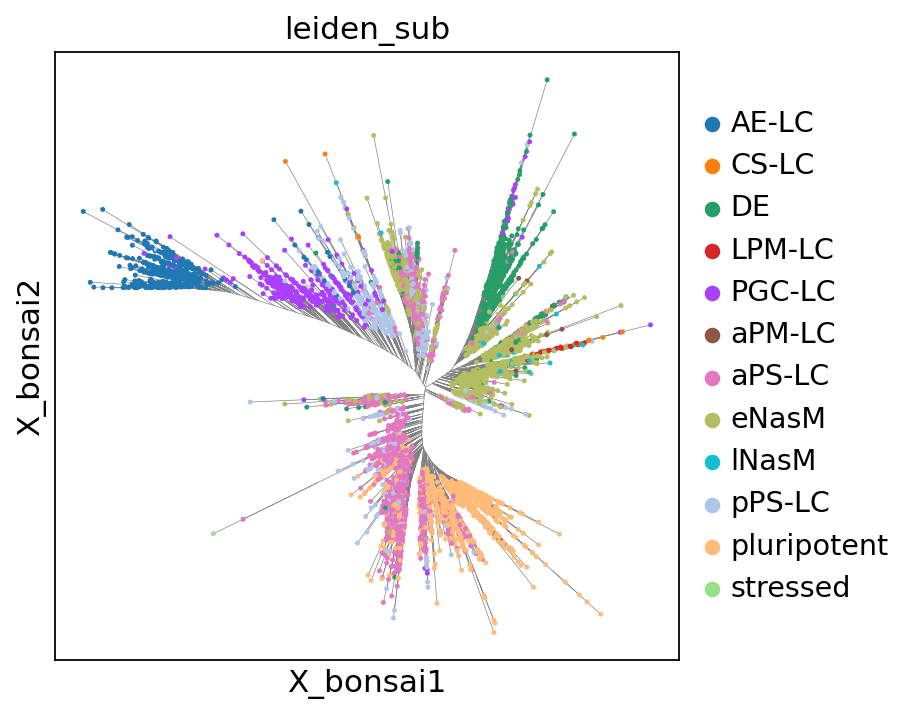

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)
# plt.savefig(
#     "bonsai_micropattern_48h-1_circular_tree_view.png", dpi=300, bbox_inches="tight"
# )

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

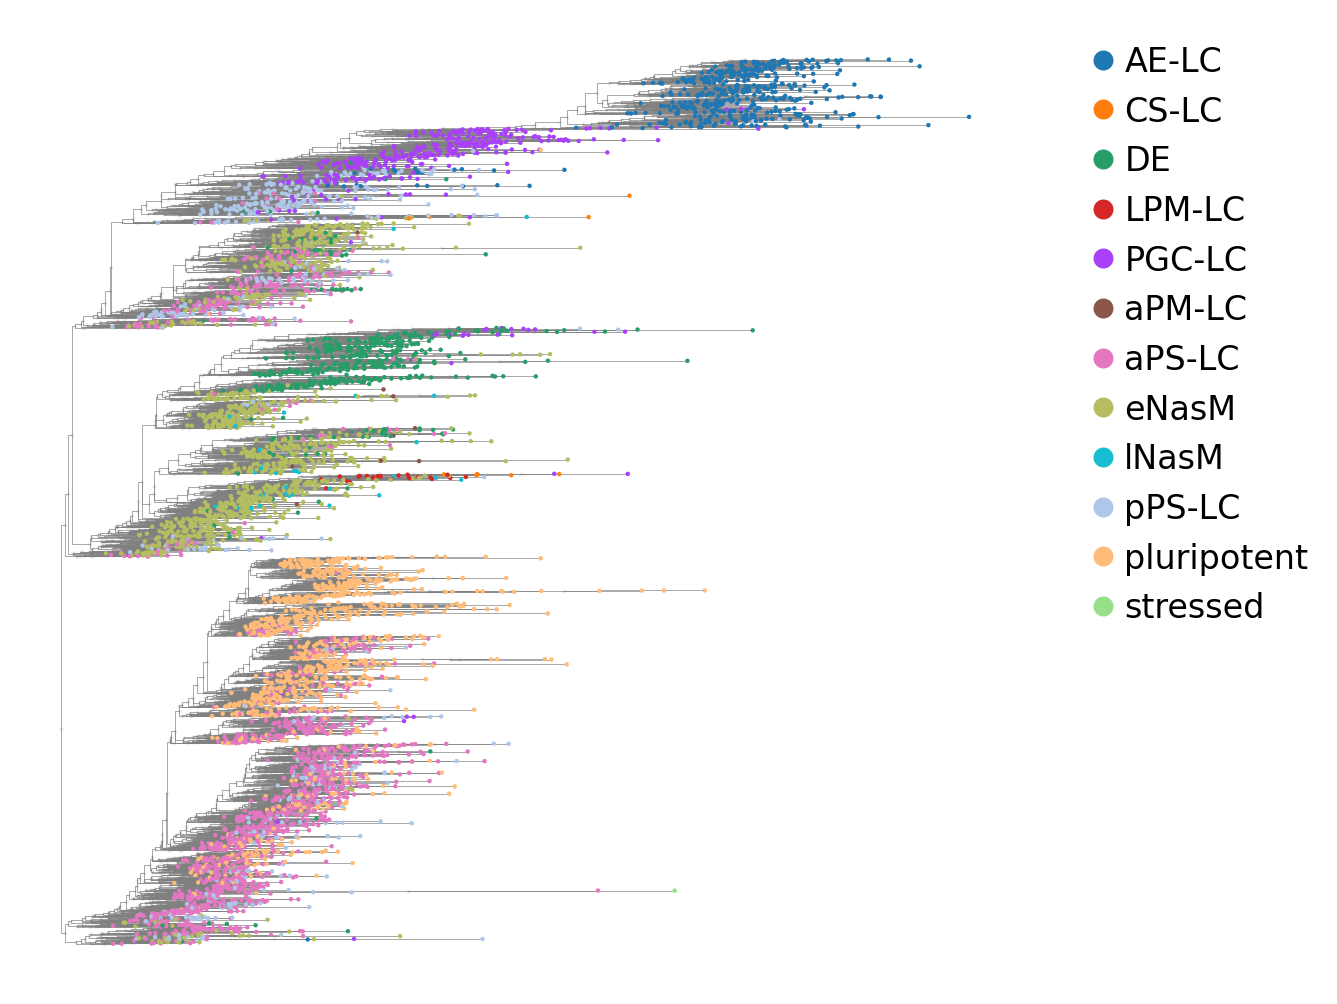

In [5]:
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
# plt.savefig("bonsai_micropattern_48h-1_rec_tree_view.png", dpi=300, bbox_inches="tight")

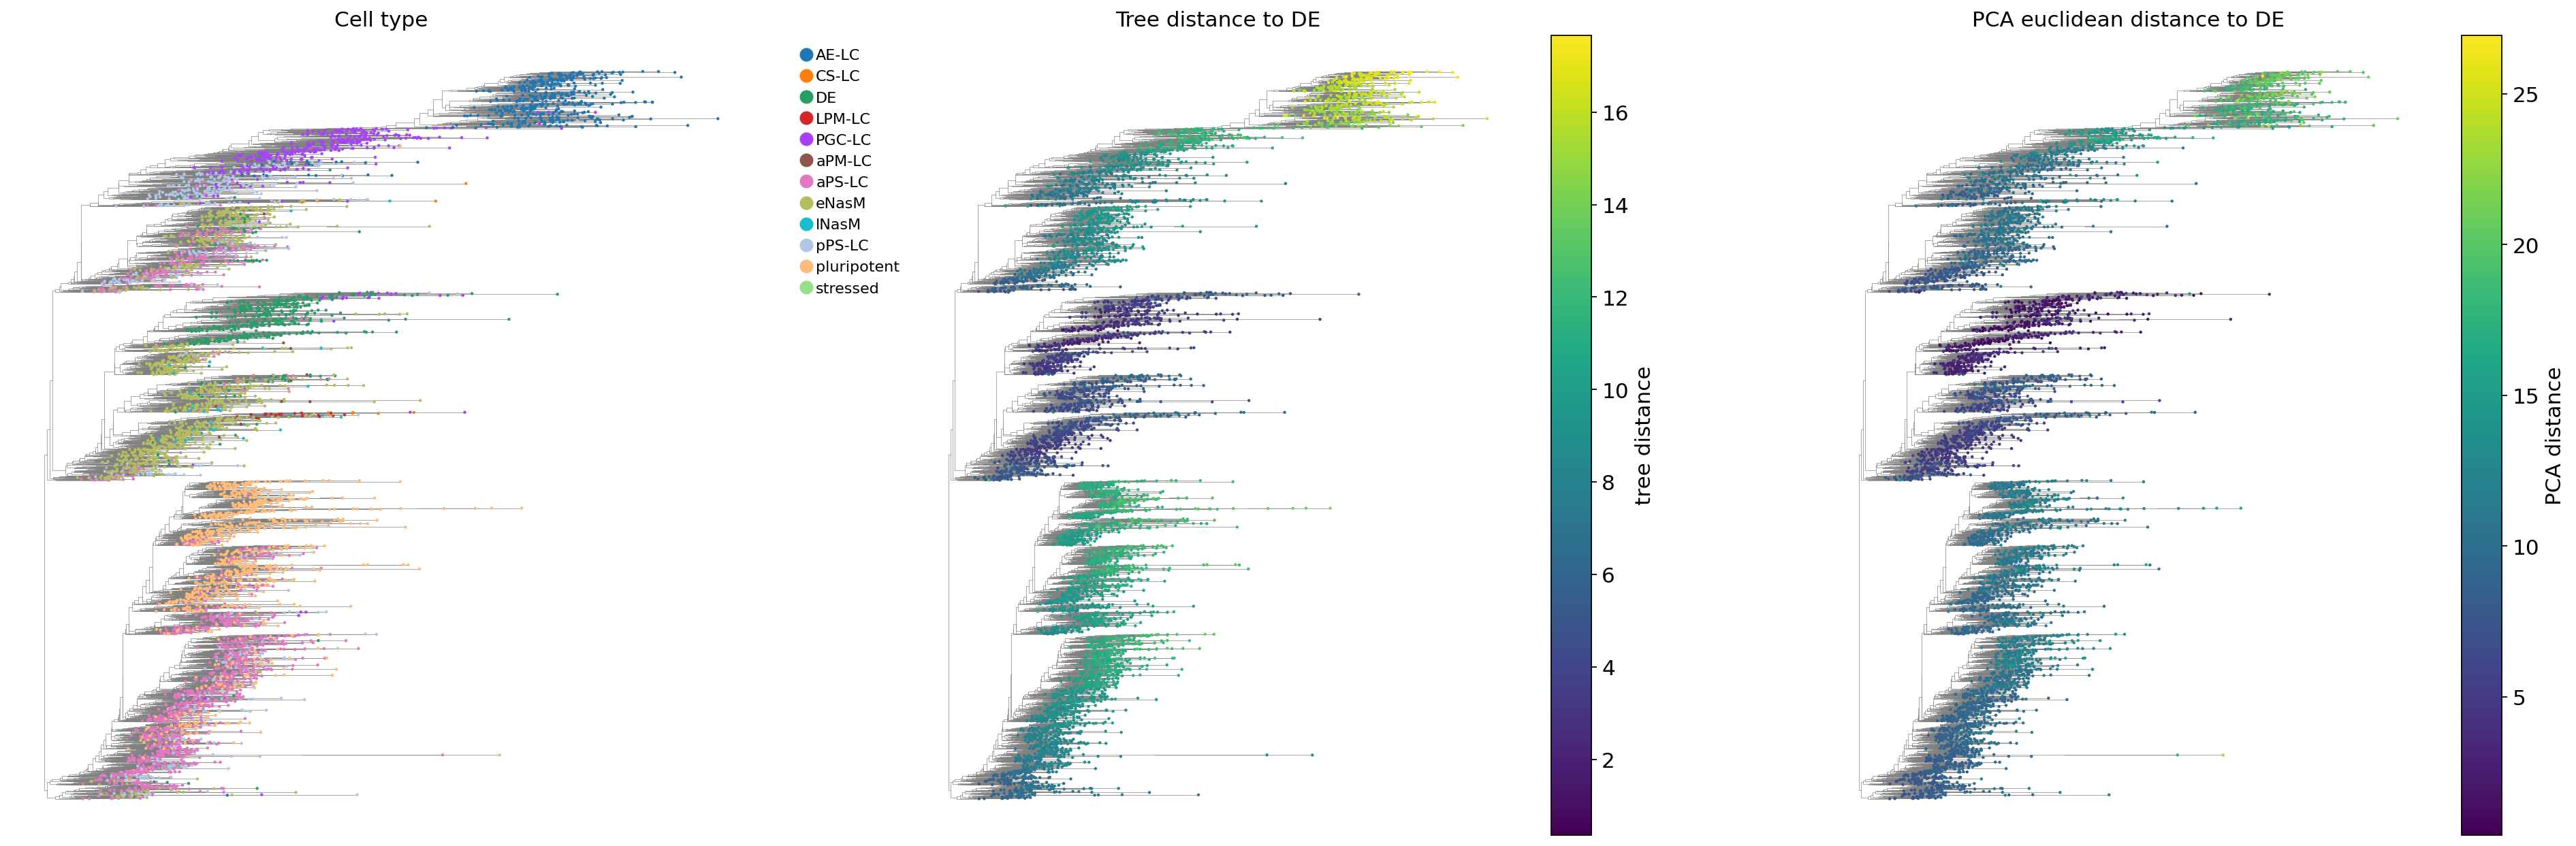

In [ ]:
import json

import networkx as nx
import numpy as np

bonsai_dir = "./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0"
with open(f"{bonsai_dir}/metadata.json") as f:
    meta = json.load(f)
gene_var = np.asarray(meta["geneVariances"], dtype=np.float64)
ltq_coords_post = np.load(f"{bonsai_dir}/posterior_ltqs_vertByGene.npy")
ltq_var_coords_post = np.load(f"{bonsai_dir}/posterior_ltqsVars_vertByGene.npy")
if ltq_coords_post.shape[1] != gene_var.shape[0]:
    raise ValueError(
        f"nGenes mismatch: ltqs {ltq_coords_post.shape[1]} vs geneVariances {gene_var.shape[0]}"
    )
v_row = gene_var[np.newaxis, :]
# gene var scaling similar as in Bonsai
ltq_coords = ltq_coords_post / np.sqrt(v_row)
ltq_var_coords = ltq_var_coords_post / v_row
source_vert = node_id_to_vert_ind["GTGCTGGTCGGTATGT-1_48h"]
G = nx.Graph()
with open(f"{bonsai_dir}/edgeInfo.txt") as f:
    for line in f:
        v1, v2, d = line.strip().split("\t")
        v1, v2 = int(v1), int(v2)
        std_child = np.sqrt(ltq_var_coords[v2])
        # 1.45 is just a heuristic, try to subtract radius of gene noise so the remaining matching t
        eucli_d = np.maximum(
            np.abs(ltq_coords[v1] - ltq_coords[v2]) - 1.45 * std_child, 0.0
        )
        eucli = float(np.linalg.norm(eucli_d))
        G.add_edge(v1, v2, weight=np.sqrt(float(d)), weight_euclidean=eucli)

# Shortest path distances (= tree path distances since it's a tree)
dists = nx.single_source_dijkstra_path_length(G, source_vert, weight="weight")
dists_eucli = nx.single_source_dijkstra_path_length(
    G, source_vert, weight="weight_euclidean"
)

# Map to cells
cell_dists = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = dists.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists[ci] = d
    else:
        cell_dists[cell_idx] = d

cell_dists_eucli = np.zeros(len(cell_ids))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    d = dists_eucli.get(vert_idx, np.nan)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_dists_eucli[ci] = d

adata.obs["tree_dist"] = cell_dists
source_cell = "GTGCTGGTCGGTATGT-1_48h"
source_idx = list(adata.obs.index).index(source_cell)
pca_root = adata.obsm["X_pca"][source_idx]
pca_dists = np.linalg.norm(adata.obsm["X_pca"] - pca_root, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Set color scale min/max for both middle and right panels
vmin, vmax = 0, 20

# Left: cell type
for e in edge_coords_d:
    axes[0].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
axes[0].scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
)
axes[0].set_aspect("auto")
axes[0].axis("off")
axes[0].set_title("Cell type")

# Middle: tree distance (with fixed color scale)
for e in edge_coords_d:
    axes[1].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc1 = axes[1].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    s=1,
    c=cell_dists,
    cmap="viridis",
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
)
plt.colorbar(sc1, ax=axes[1], label="tree distance")
axes[1].set_aspect("auto")
axes[1].axis("off")
axes[1].set_title("Tree distance to DE")

# Right: euclidean distance (with fixed color scale)
for e in edge_coords_d:
    axes[2].plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc2 = axes[2].scatter(
    cell_coords_d[:, 0],
    cell_coords_d[:, 1],
    s=1,
    c=cell_dists_eucli,
    cmap="viridis",
    zorder=3,
    # vmin=vmin,
    # vmax=vmax,
)
plt.colorbar(sc2, ax=axes[2], label="PCA distance")
axes[2].set_aspect("auto")

axes[2].axis("off")
axes[2].set_title("PCA euclidean distance to DE")

plt.tight_layout()
# plt.savefig("bonsai_micropattern_48h-1_tree.png", dpi=300, bbox_inches="tight")

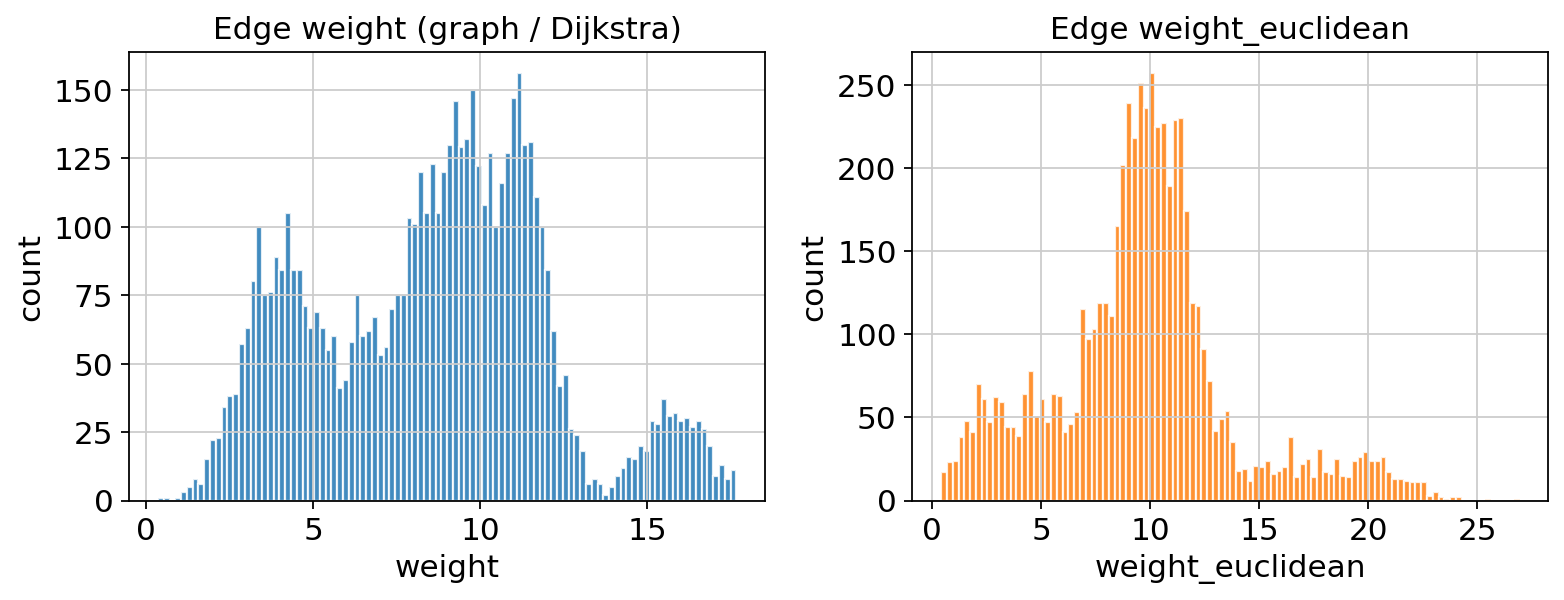

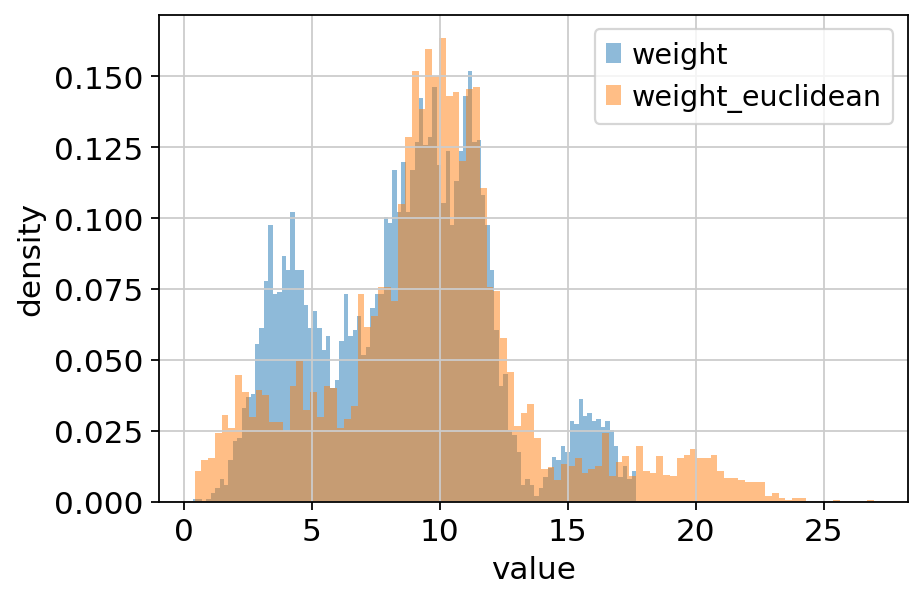

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# w_graph = []
# w_euclid = []
# for _, _, data in G.edges(data=True):
#     w_graph.append(data["weight"])
#     w_euclid.append(data["weight_euclidean"])

w_graph = cell_dists
w_euclid = cell_dists_eucli

# w_graph = w_graph[w_graph > 0]
# w_euclid = w_euclid[w_euclid > 0]
# w_graph_min = np.min(w_graph)

# w_euclid = (w_euclid - np.min(w_euclid)) / (np.max(w_euclid) - np.min(w_euclid))
# w_graph = (w_graph - np.min(w_graph)) / (np.max(w_graph) - np.min(w_graph))

# w_euclid = w_euclid + w_graph_min
# w_graph = w_graph + w_graph_min

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(w_graph, bins=100, color="C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Edge weight (graph / Dijkstra)")
axes[0].set_xlabel("weight")
axes[0].set_ylabel("count")

axes[1].hist(w_euclid, bins=100, color="C1", alpha=0.85, edgecolor="white")
axes[1].set_title("Edge weight_euclidean")
axes[1].set_xlabel("weight_euclidean")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

# Optional: same scale overlay (log-y helps if heavy-tailed)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(w_graph, bins=100, alpha=0.5, label="weight", density=True)
ax.hist(w_euclid, bins=100, alpha=0.5, label="weight_euclidean", density=True)
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.legend()
plt.show()

In [ ]:
# for web app
# adata.obs.to_csv(
#     "./heemskerk_data/adata_timeseries_old_48h-1_meta.csv", index_label="cellID"
# )

# Optimize tree

In [6]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/vertInfo.txt") as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_1924"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

In [7]:
adata = sc.read_h5ad(
    "./heemskerk_data/adata_timeseries_old_48h-1_with_loop_and_bonsai_cluster_hodge.h5ad"
)

In [8]:
# adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

In [9]:
import micropattern as mic

adata.obs["in_loop_knn"] = (
    adata.obs["in_loop"].cat.add_categories("none").fillna("none")
)
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=10)
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pred_lab["in_loop_knn"]
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=15)  # 50
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"])
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=10)  # 30
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"]).remove_categories(
    "none"
)
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"


adata.obs.loc[adata.obs["dpt_pseudotime"] < 0.11, "in_loop_knn"] = None

Weighted KNN with n_neighbors = 10 ... 

/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

finished!
Weighted KNN with n_neighbors = 15 ... finished!


/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

Weighted KNN with n_neighbors = 10 ... finished!


In [10]:
import micropattern as mic

adata_tmp = adata[~np.isnan(adata.obs["PGC-DE_hodge"])].copy()
adata_tmp.obsm["PGC-DE_hodge"] = adata_tmp.obs["PGC-DE_hodge"].values[:, None]
mic.knn.knn_transfer_layout(
    adata_tmp,
    adata,
    "X_diffmap",
    layout_key="PGC-DE_hodge",
    n_neighbors=10,
    key_added="PGC-DE_hodge_knn",
)
adata.obs["PGC-DE_hodge_knn"] = adata.obsm["PGC-DE_hodge_knn"].astype(float)
adata.obs.loc[pd.isna(adata.obs["in_loop_knn"]), "PGC-DE_hodge_knn"] = np.nan
adata.obs["PGC-DE_hodge_knn"] = adata.obs["PGC-DE_hodge_knn"] + 0.001
adata.obs.loc[adata.obs["PGC-DE_hodge_knn"] < 0, "PGC-DE_hodge_knn"] = (
    adata.obs.loc[adata.obs["PGC-DE_hodge_knn"] < 0, "PGC-DE_hodge_knn"] - 0.0001
)
adata.obs.loc[
    np.logical_and(
        adata.obs["PGC-DE_hodge_knn"] < 0, adata.obs["dpt_pseudotime"] > 0.18
    ),
    "PGC-DE_hodge_knn",
] = adata.obs.loc[
    np.logical_and(
        adata.obs["PGC-DE_hodge_knn"] < 0, adata.obs["dpt_pseudotime"] > 0.14
    ),
    "PGC-DE_hodge_knn",
] + 2.5 * (
    0.0001
    + np.abs(
        np.array(
            adata.obs.loc[
                np.logical_and(
                    adata.obs["PGC-DE_hodge_knn"] < 0,
                    adata.obs["dpt_pseudotime"] > 0.14,
                ),
                "PGC-DE_hodge_knn",
            ]
        )
    )
)

adata.obs["branch1"] = adata.obs["PGC-DE_hodge_knn"] > -0.0005
adata.obs["branch2"] = adata.obs["PGC-DE_hodge_knn"] < -0.0005

Weighted KNN with n_neighbors = 10 ... 

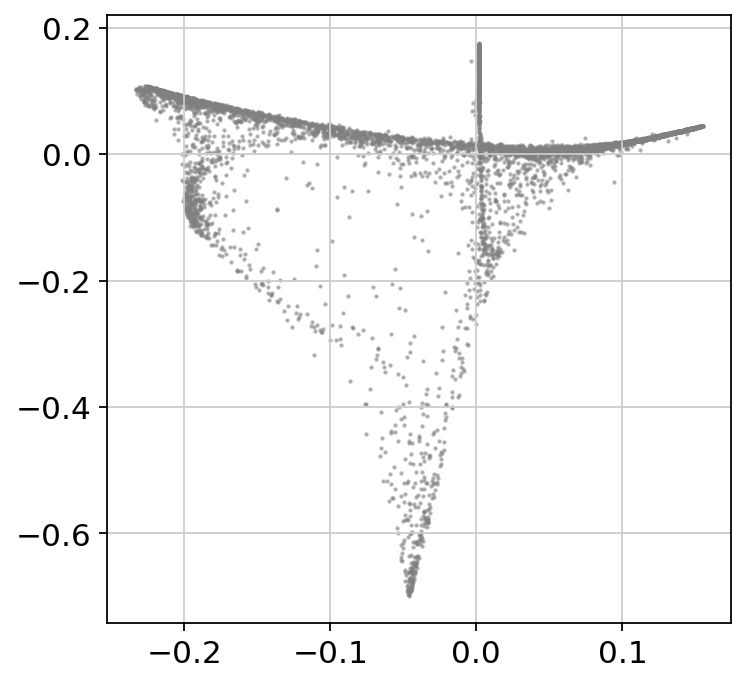

In [11]:
plt.scatter(
    adata.obsm["X_diffmap"][:, 1],
    adata.obsm["X_diffmap"][:, 2],
    s=1,
    c="gray",
    alpha=0.5,
)

<Axes: title={'center': 'dpt_pseudotime'}, xlabel='DC2', ylabel='DC3'>

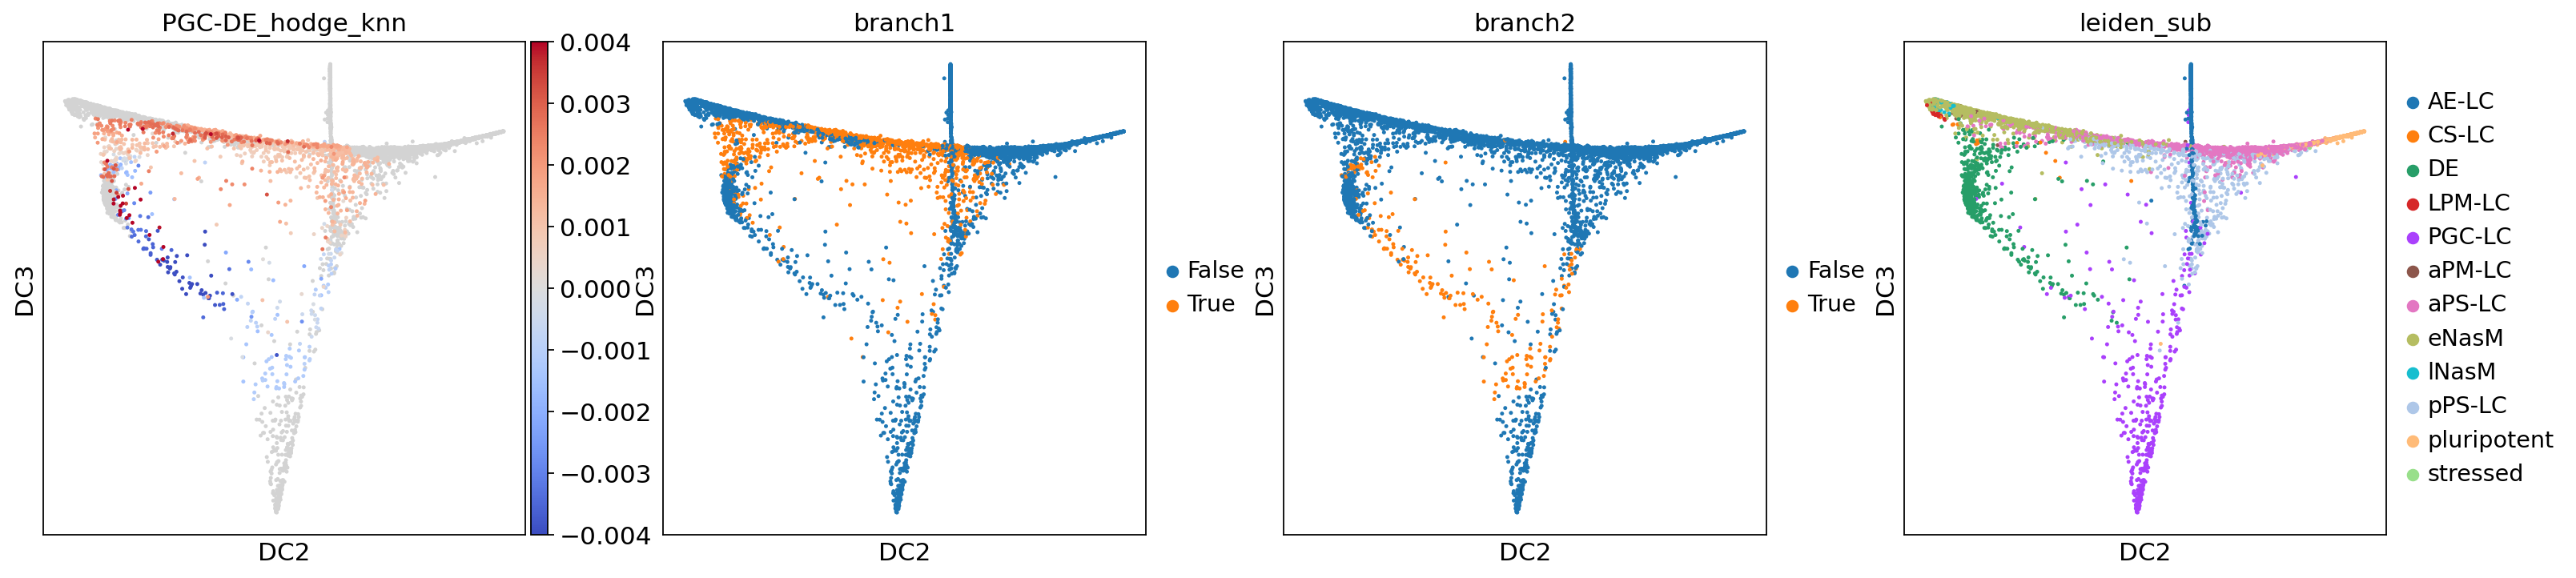

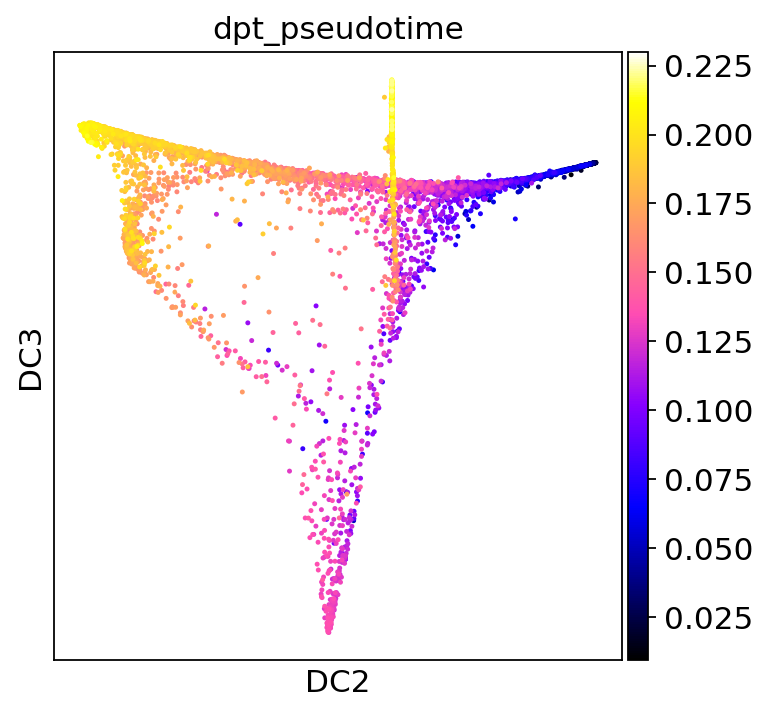

In [18]:
sc.pl.diffmap(
    adata,
    color=["PGC-DE_hodge_knn", "branch1", "branch2", "leiden_sub"],
    s=20,
    show=False,
    components=["2,3"],
    vmin=-0.004,
    vmax=0.004,
    cmap="coolwarm",
)
sc.pl.diffmap(
    adata,
    color=["dpt_pseudotime"],
    s=20,
    show=False,
    components=["2,3"],
    cmap="gnuplot2",
)

In [ ]:
adata.obs["dpt_pseudotime_old"] = adata.obs["dpt_pseudotime"].copy()

In [55]:
adata.obs["dpt_pseudotime"] = adata.obs["dpt_pseudotime_old"].copy()

In [ ]:
adata.obsm["X_diffmap_old"] = adata.obsm["X_diffmap"].copy()
if "X_diffmap" in adata.obsm:
    del adata.obsm["X_diffmap"]

In [ ]:
s = adata.obs.loc[~pd.isna(adata.obs["PGC-DE_hodge_knn"]), "dpt_pseudotime"]
qv = s.quantile(0.95)
terminal = (s - qv).abs().idxmin()
adata.uns["iroot"] = np.where(adata.obs.index == terminal)[0][0]
# sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=25, method="gauss")
# sc.tl.diffmap(adata)
# sc.tl.dpt(adata)
terminal_coord = adata.obsm["X_diffmap_old"][adata.uns["iroot"]]
s = np.array([0.99257274, 0.98538962, 0.97102565, 0.95238358])
delta = adata.obsm["X_diffmap_old"] - terminal_coord
adata.obs["dpt_pseudotime_new"] = np.sqrt(np.sum((delta[:, :3] ** 2) * s[:3], axis=1))

In [76]:
adata.obsm["X_diffmap"] = adata.obsm["X_diffmap_old"].copy()

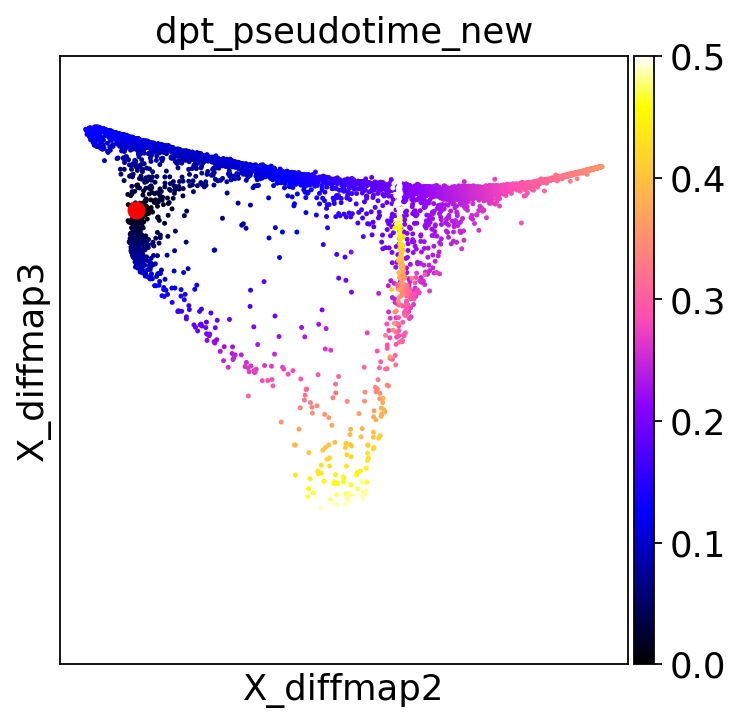

In [317]:
ax = sc.pl.embedding(
    adata,
    color=["dpt_pseudotime_new"],
    basis="X_diffmap",
    s=20,
    show=False,
    components=["2,3"],
    cmap="gnuplot2",
    vmax=0.5,
)
ax.scatter(
    adata.obsm["X_diffmap"][adata.uns["iroot"], 1],
    adata.obsm["X_diffmap"][adata.uns["iroot"], 2],
    s=50,
    c="red",
)

[<Axes: title={'center': 'in_loop_knn'}, xlabel='DC3', ylabel='DC4'>,
 <Axes: title={'center': 'in_loop_knn_uncert'}, xlabel='DC3', ylabel='DC4'>]

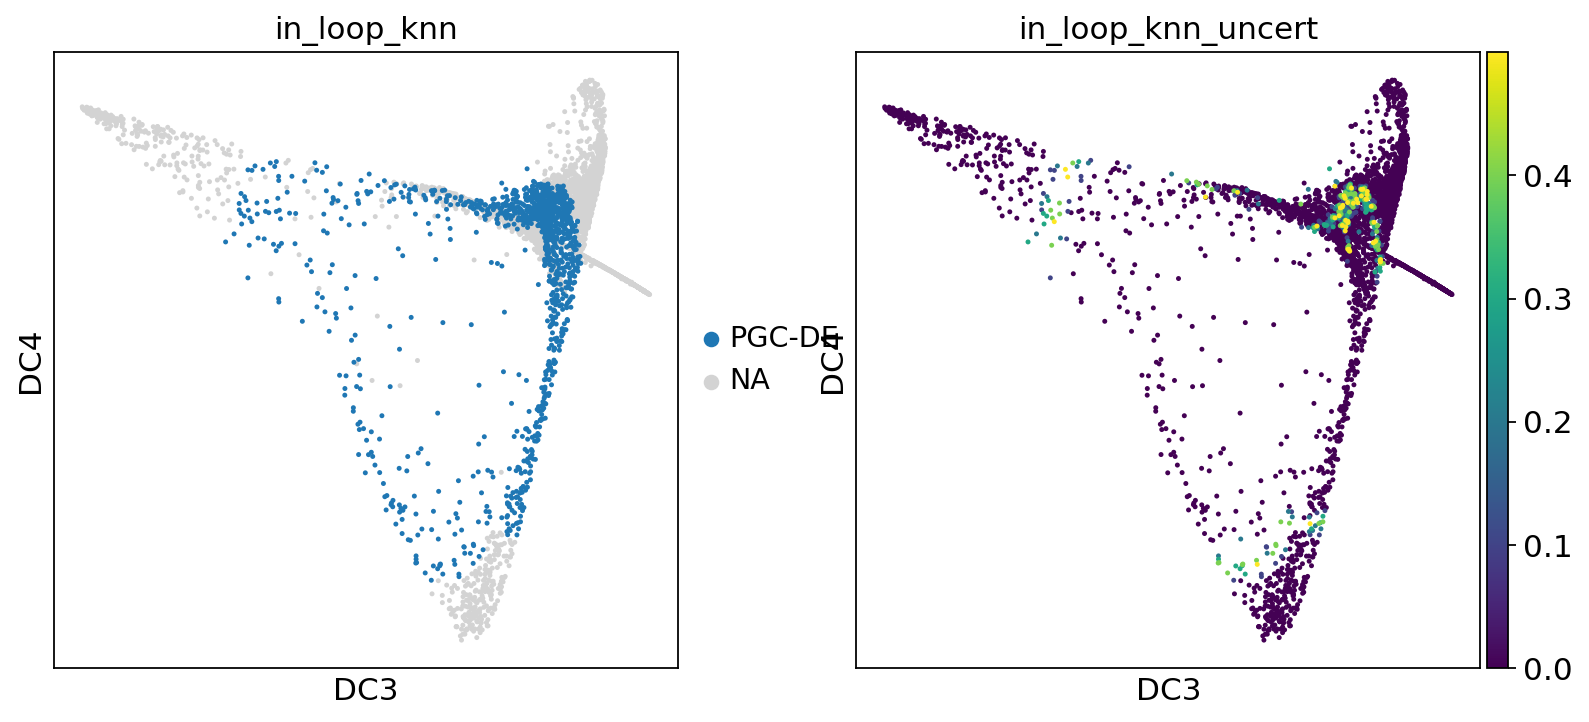

In [15]:
sc.pl.diffmap(
    adata,
    color=["in_loop_knn", "in_loop_knn_uncert"],
    s=20,
    show=False,
    components=["3,4"],
)

[<Axes: title={'center': 'in_loop_knn'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>,
 <Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>]

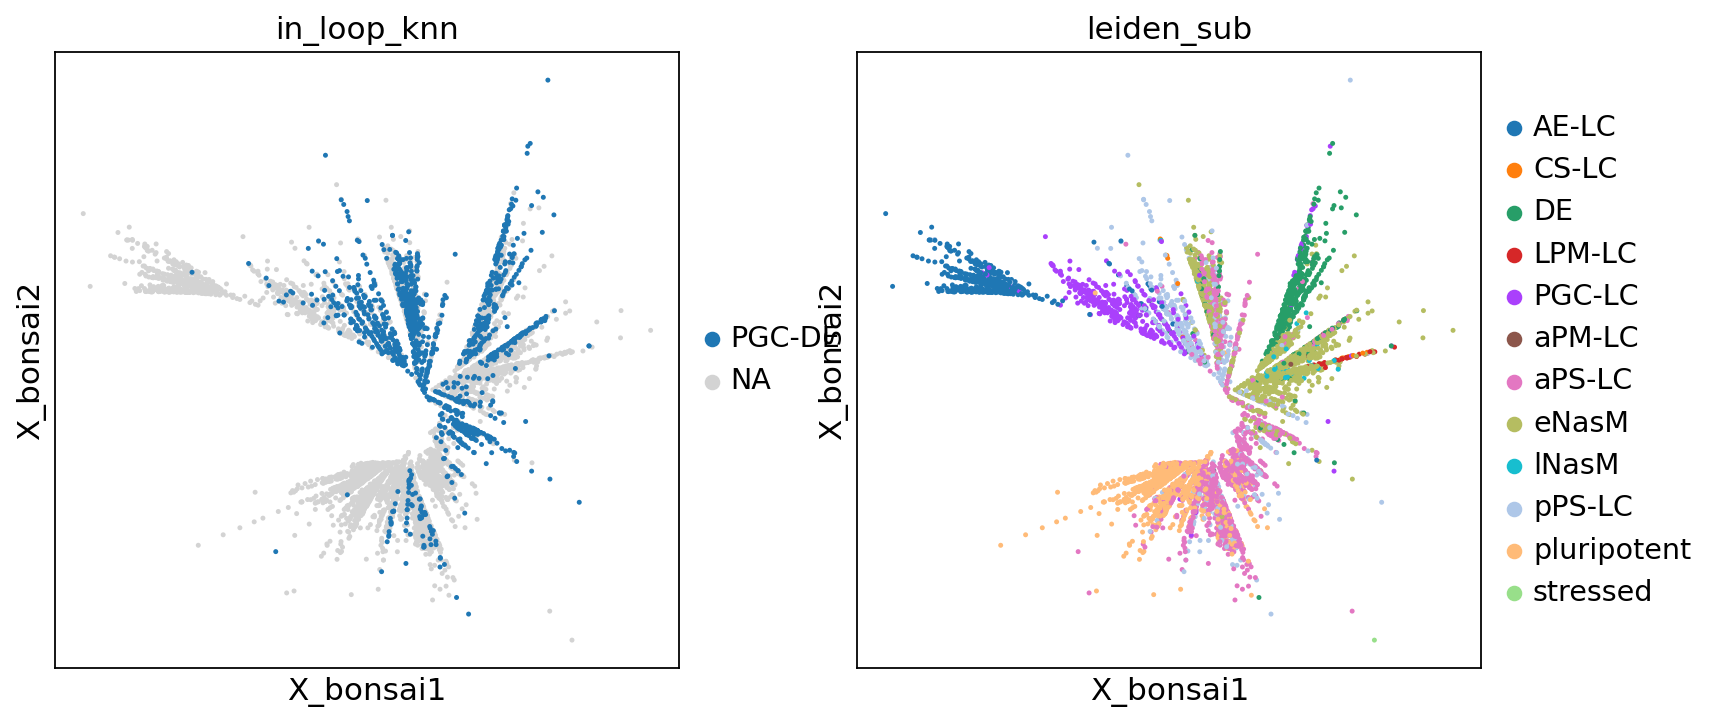

In [78]:
# fig, ax = plt.subplots(figsize=(5, 5))
# for e in edge_coords:
#     ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color=["in_loop_knn", "leiden_sub"],
    # ax=ax,
    show=False,
    s=20,
    zorder=2,
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

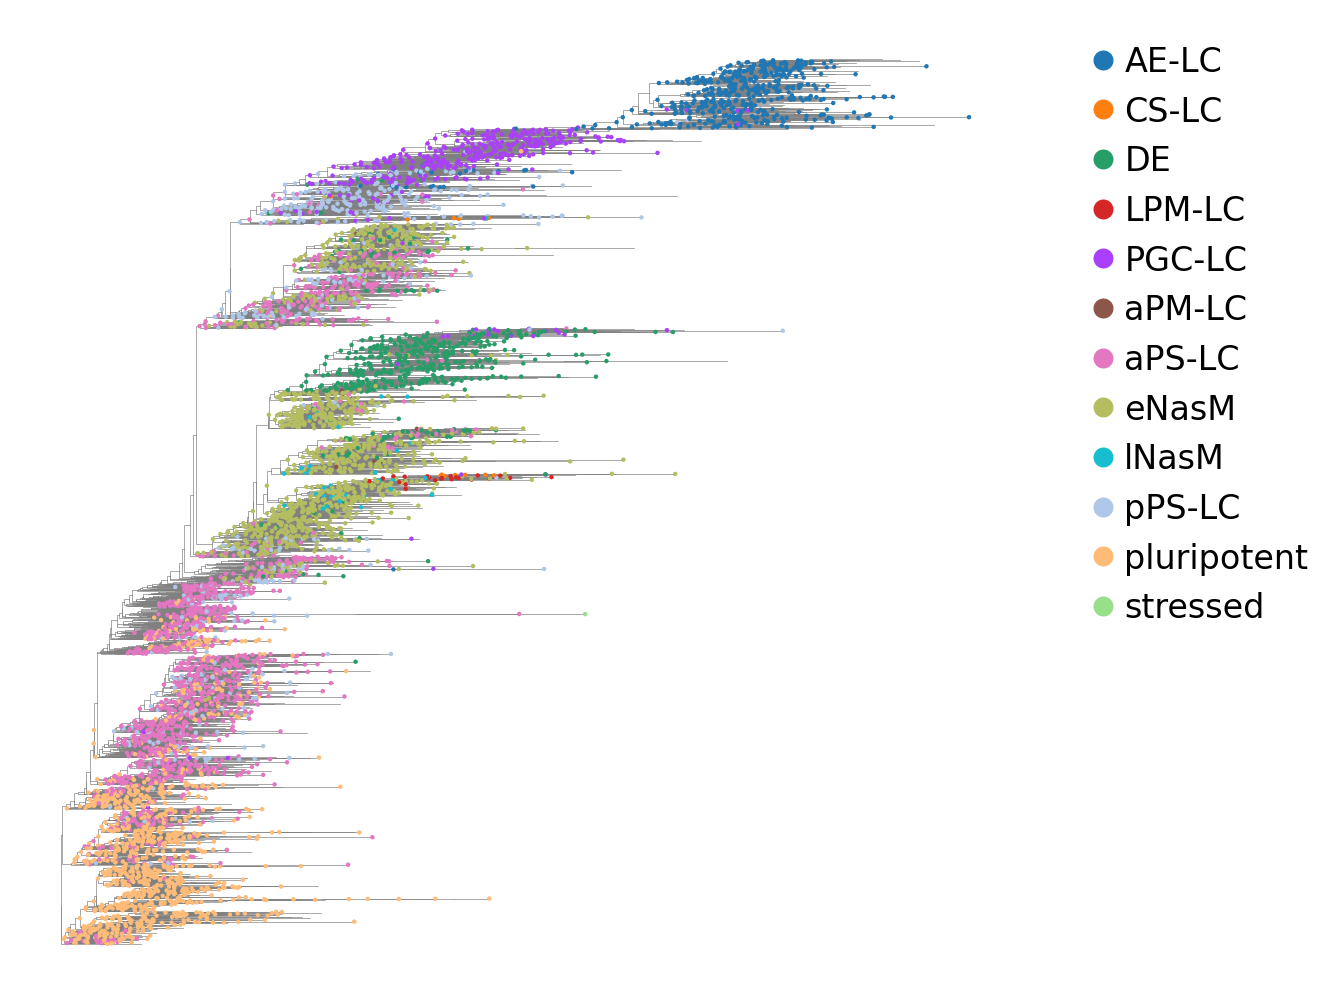

In [31]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [79]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-24 12:40:48 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5168597534963729.
03-24 12:40:48 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.5906816877586086.
03-24 12:40:49 mp_print INFO 
After making 8 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-24 12:40:49 mp_print INFO Final annotation-based clustering did 8 moves, created 8 clusters, with a Normalized Mutual Information of 0.6125171516544274.
03-24 12:40:49 mp_print INFO Clustering done


In [80]:
adata.obs["bonsai_knn"] = adata.obs["bonsai_cluster"]

<Axes: title={'center': 'leiden_sub'}, xlabel='DC3', ylabel='DC4'>

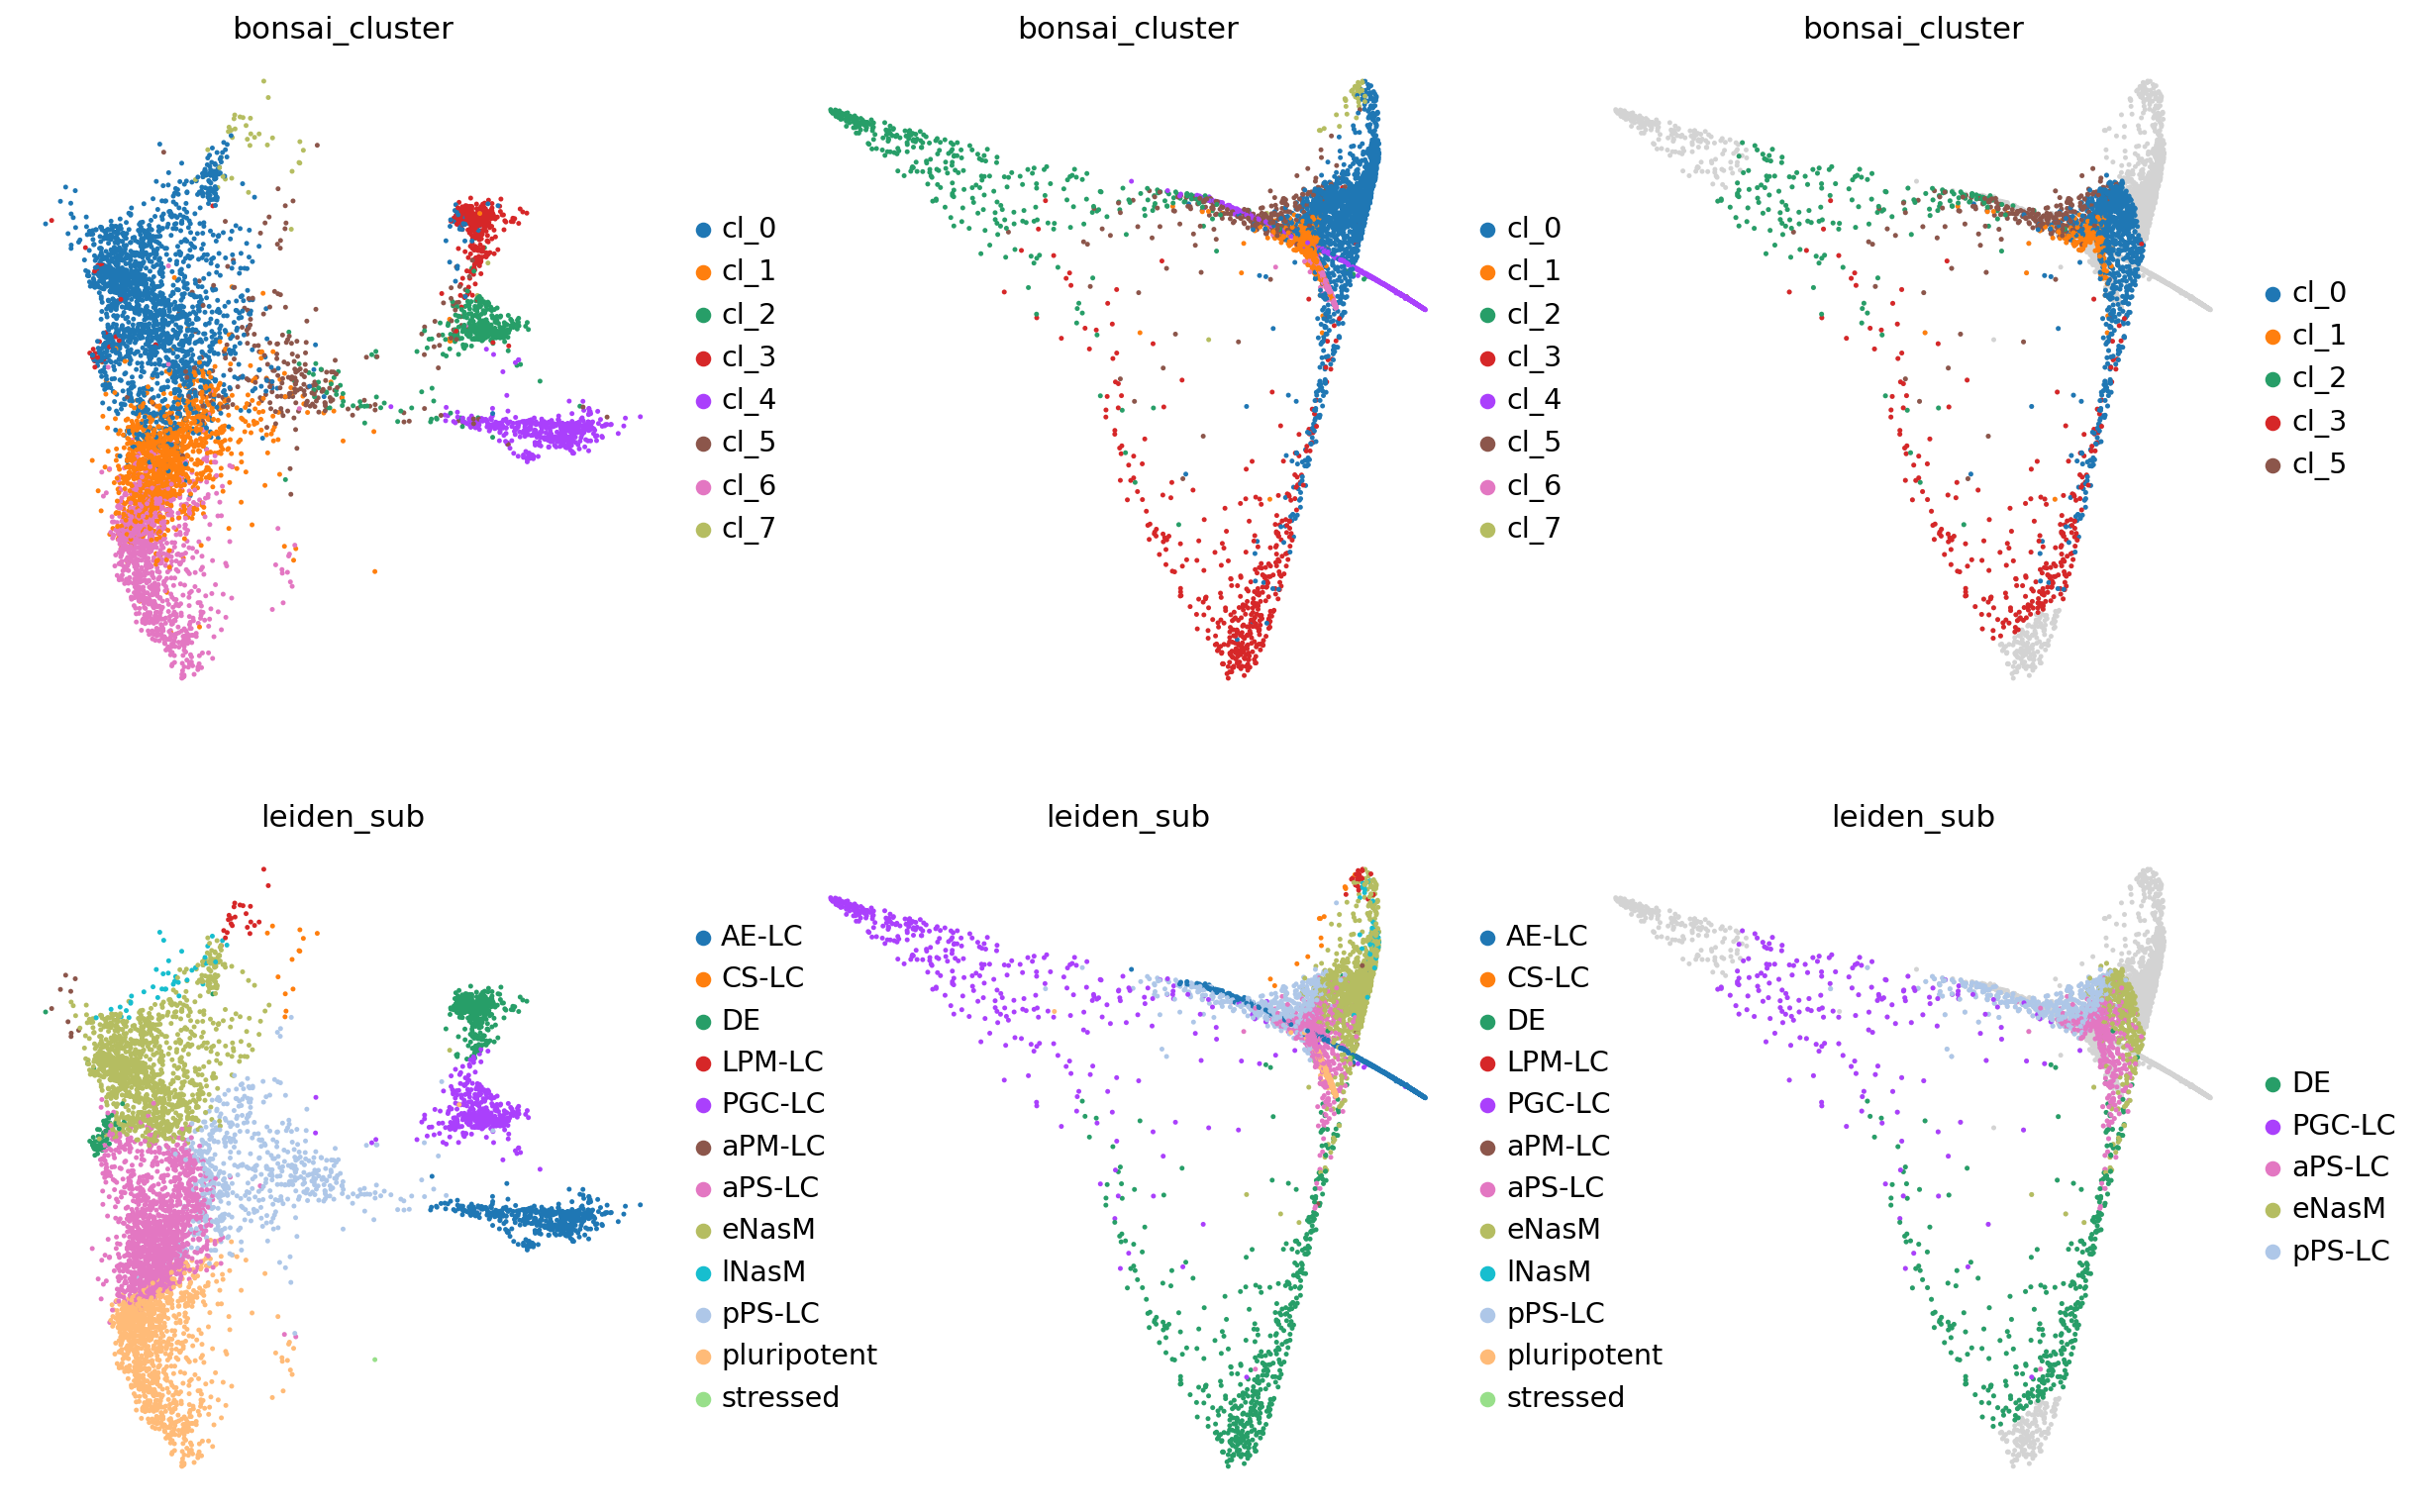

In [176]:
fig, axes = plt.subplots(2, 3, figsize=(24 * 0.75, 16 * 0.75))
adata_sub = adata[~pd.isna(adata.obs["in_loop_knn"])]
bonsai_counts = adata_sub.obs["bonsai_cluster"].value_counts()
min_counts = bonsai_counts.min() * 10
adata_sub = adata_sub[
    adata_sub.obs["bonsai_cluster"].map(bonsai_counts).astype(int) > min_counts
]
ax = axes[0, 0]
sc.pl.umap(
    adata,
    s=20,
    show=False,
    color="bonsai_cluster",
    ax=ax,
    frameon=False,
)
ax = axes[1, 0]
sc.pl.umap(
    adata,
    s=20,
    show=False,
    color="leiden_sub",
    ax=ax,
    frameon=False,
)
ax = axes[0, 1]
sc.pl.diffmap(
    adata,
    s=20,
    show=False,
    color="bonsai_cluster",
    components=["3,4"],
    ax=ax,
    frameon=False,
)
ax = axes[1, 1]
sc.pl.diffmap(
    adata,
    s=20,
    show=False,
    color="leiden_sub",
    components=["3,4"],
    ax=ax,
    frameon=False,
)
ax = axes[0, 2]
sc.pl.diffmap(adata, s=20, show=False, components=["3,4"], ax=ax)
sc.pl.diffmap(
    adata_sub,
    s=20,
    show=False,
    components=["3,4"],
    color="bonsai_cluster",
    ax=ax,
    frameon=False,
)
ax = axes[1, 2]
leiden_sub_counts = adata_sub.obs["leiden_sub"].value_counts()
min_leiden_sub_counts = leiden_sub_counts.min() * 10
adata_sub = adata_sub[
    adata_sub.obs["leiden_sub"].map(leiden_sub_counts).astype(int)
    > min_leiden_sub_counts
]
sc.pl.diffmap(adata, s=20, show=False, components=["3,4"], ax=ax)
sc.pl.diffmap(
    adata_sub,
    s=20,
    show=False,
    components=["3,4"],
    color="leiden_sub",
    ax=ax,
    frameon=False,
)

In [180]:
adata.obs["in_loop_knn_uncert"] = adata.obs["in_loop_knn_uncert"].astype(float)
adata.obs["bonsai_knn_uncert"] = adata.obs["bonsai_knn_uncert"].astype(float)
adata.write_h5ad(
    "./heemskerk_data/adata_timeseries_old_48h-1_with_loop_and_bonsai_cluster.h5ad"
)

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

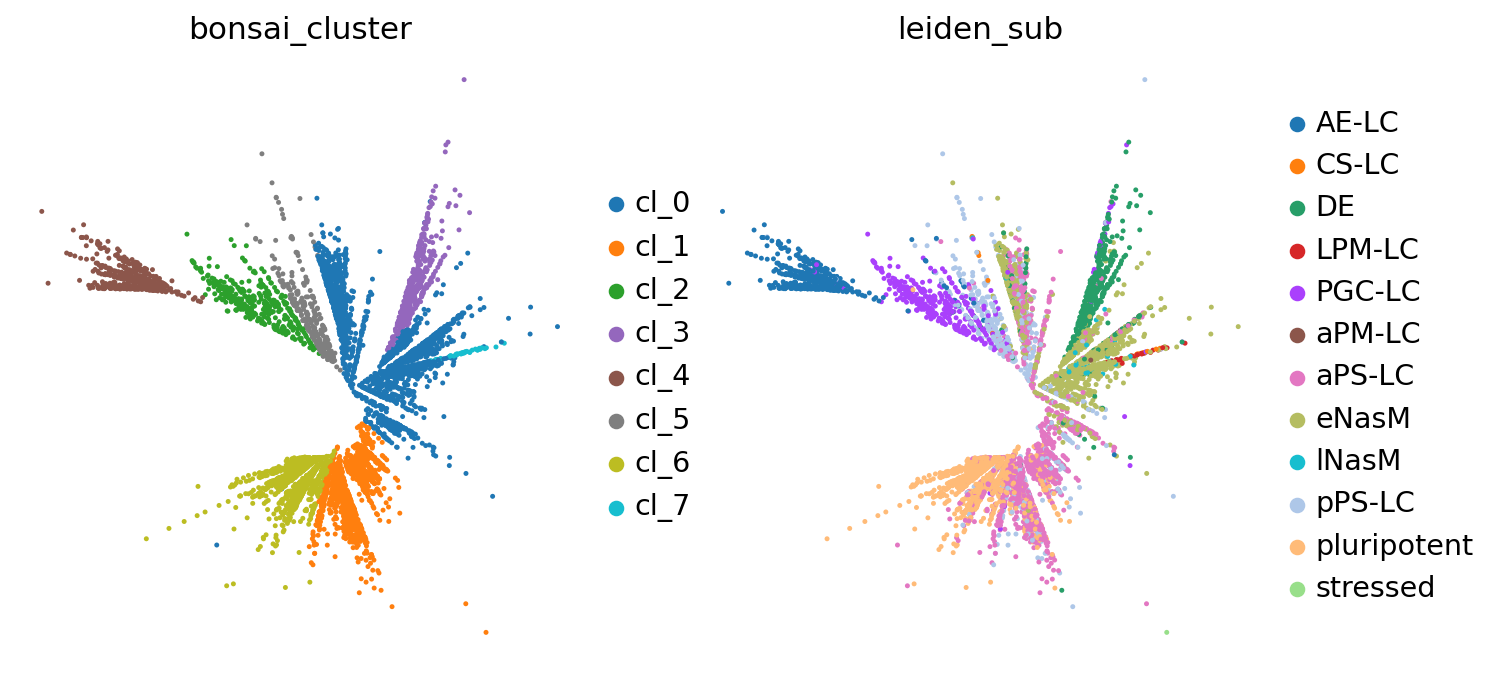

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
    frameon=False,
)

In [81]:
adata.obsm["X_umap"] = adata.obs.loc[
    :, ["umap_old_48-96h_x", "umap_old_48-96h_y"]
].values

<Axes: title={'center': 'leiden_sub'}, xlabel='UMAP1', ylabel='UMAP2'>

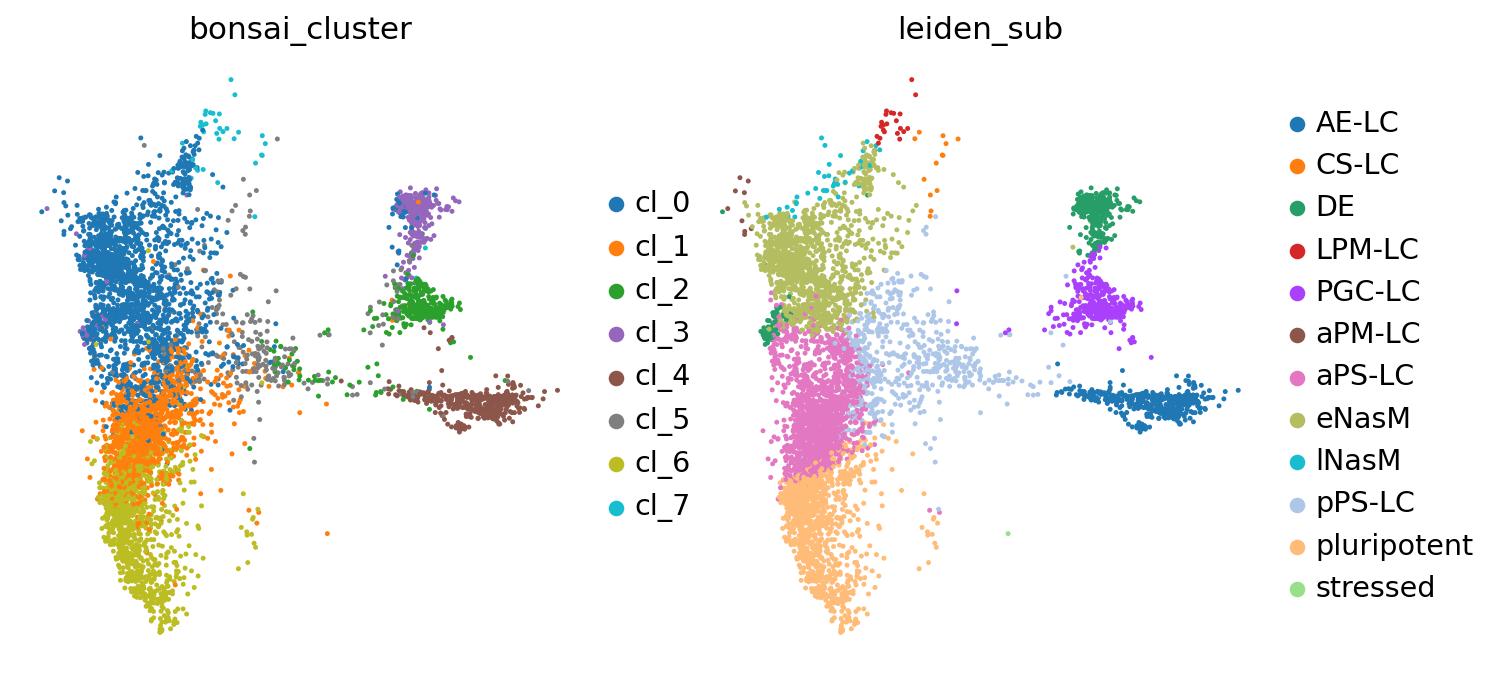

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(
    adata,
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
sc.pl.umap(
    adata,
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
    frameon=False,
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

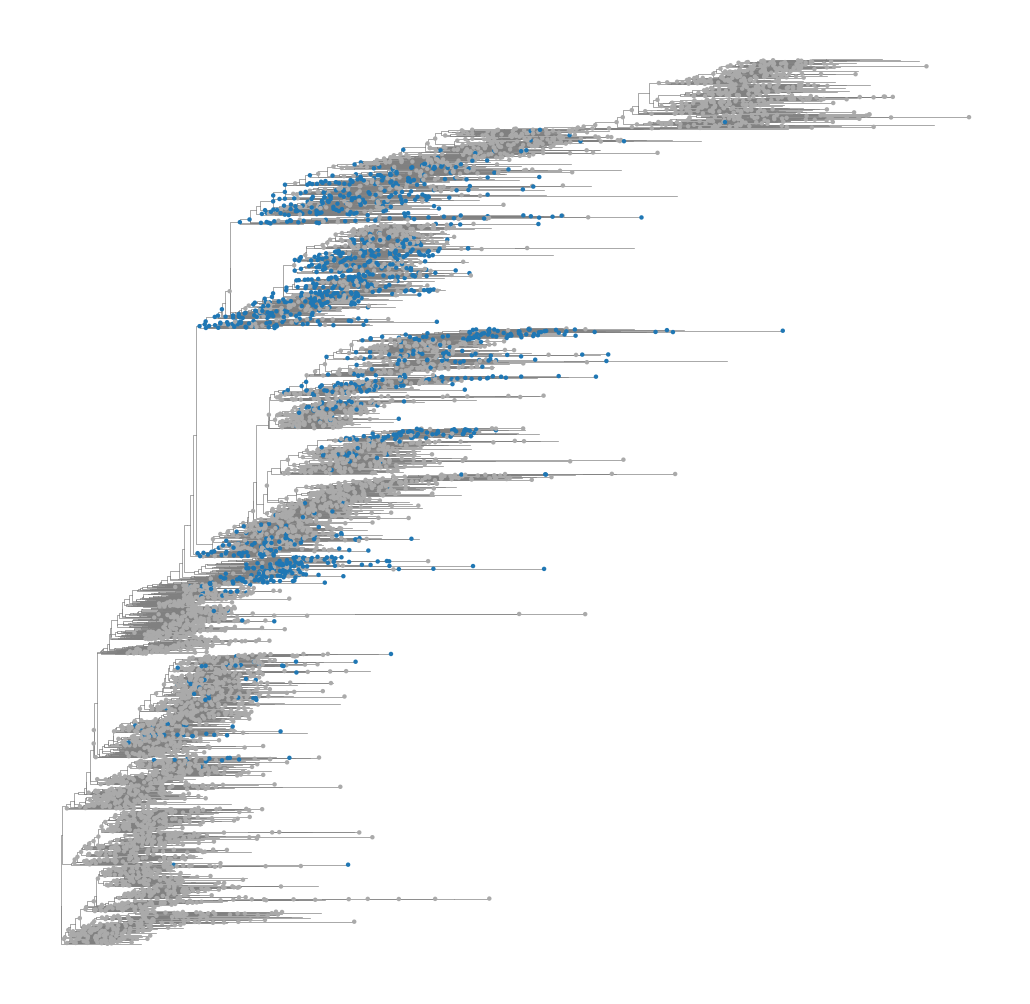

In [83]:
colors = adata.uns["in_loop_knn_colors"]
categories = adata.obs["in_loop_knn"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["in_loop_knn"].map(cat_to_color).values
cell_colors = [c if c is not np.nan else "#AAAAAA" for c in cell_colors]

fig, ax = plt.subplots(figsize=(8, 8))
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

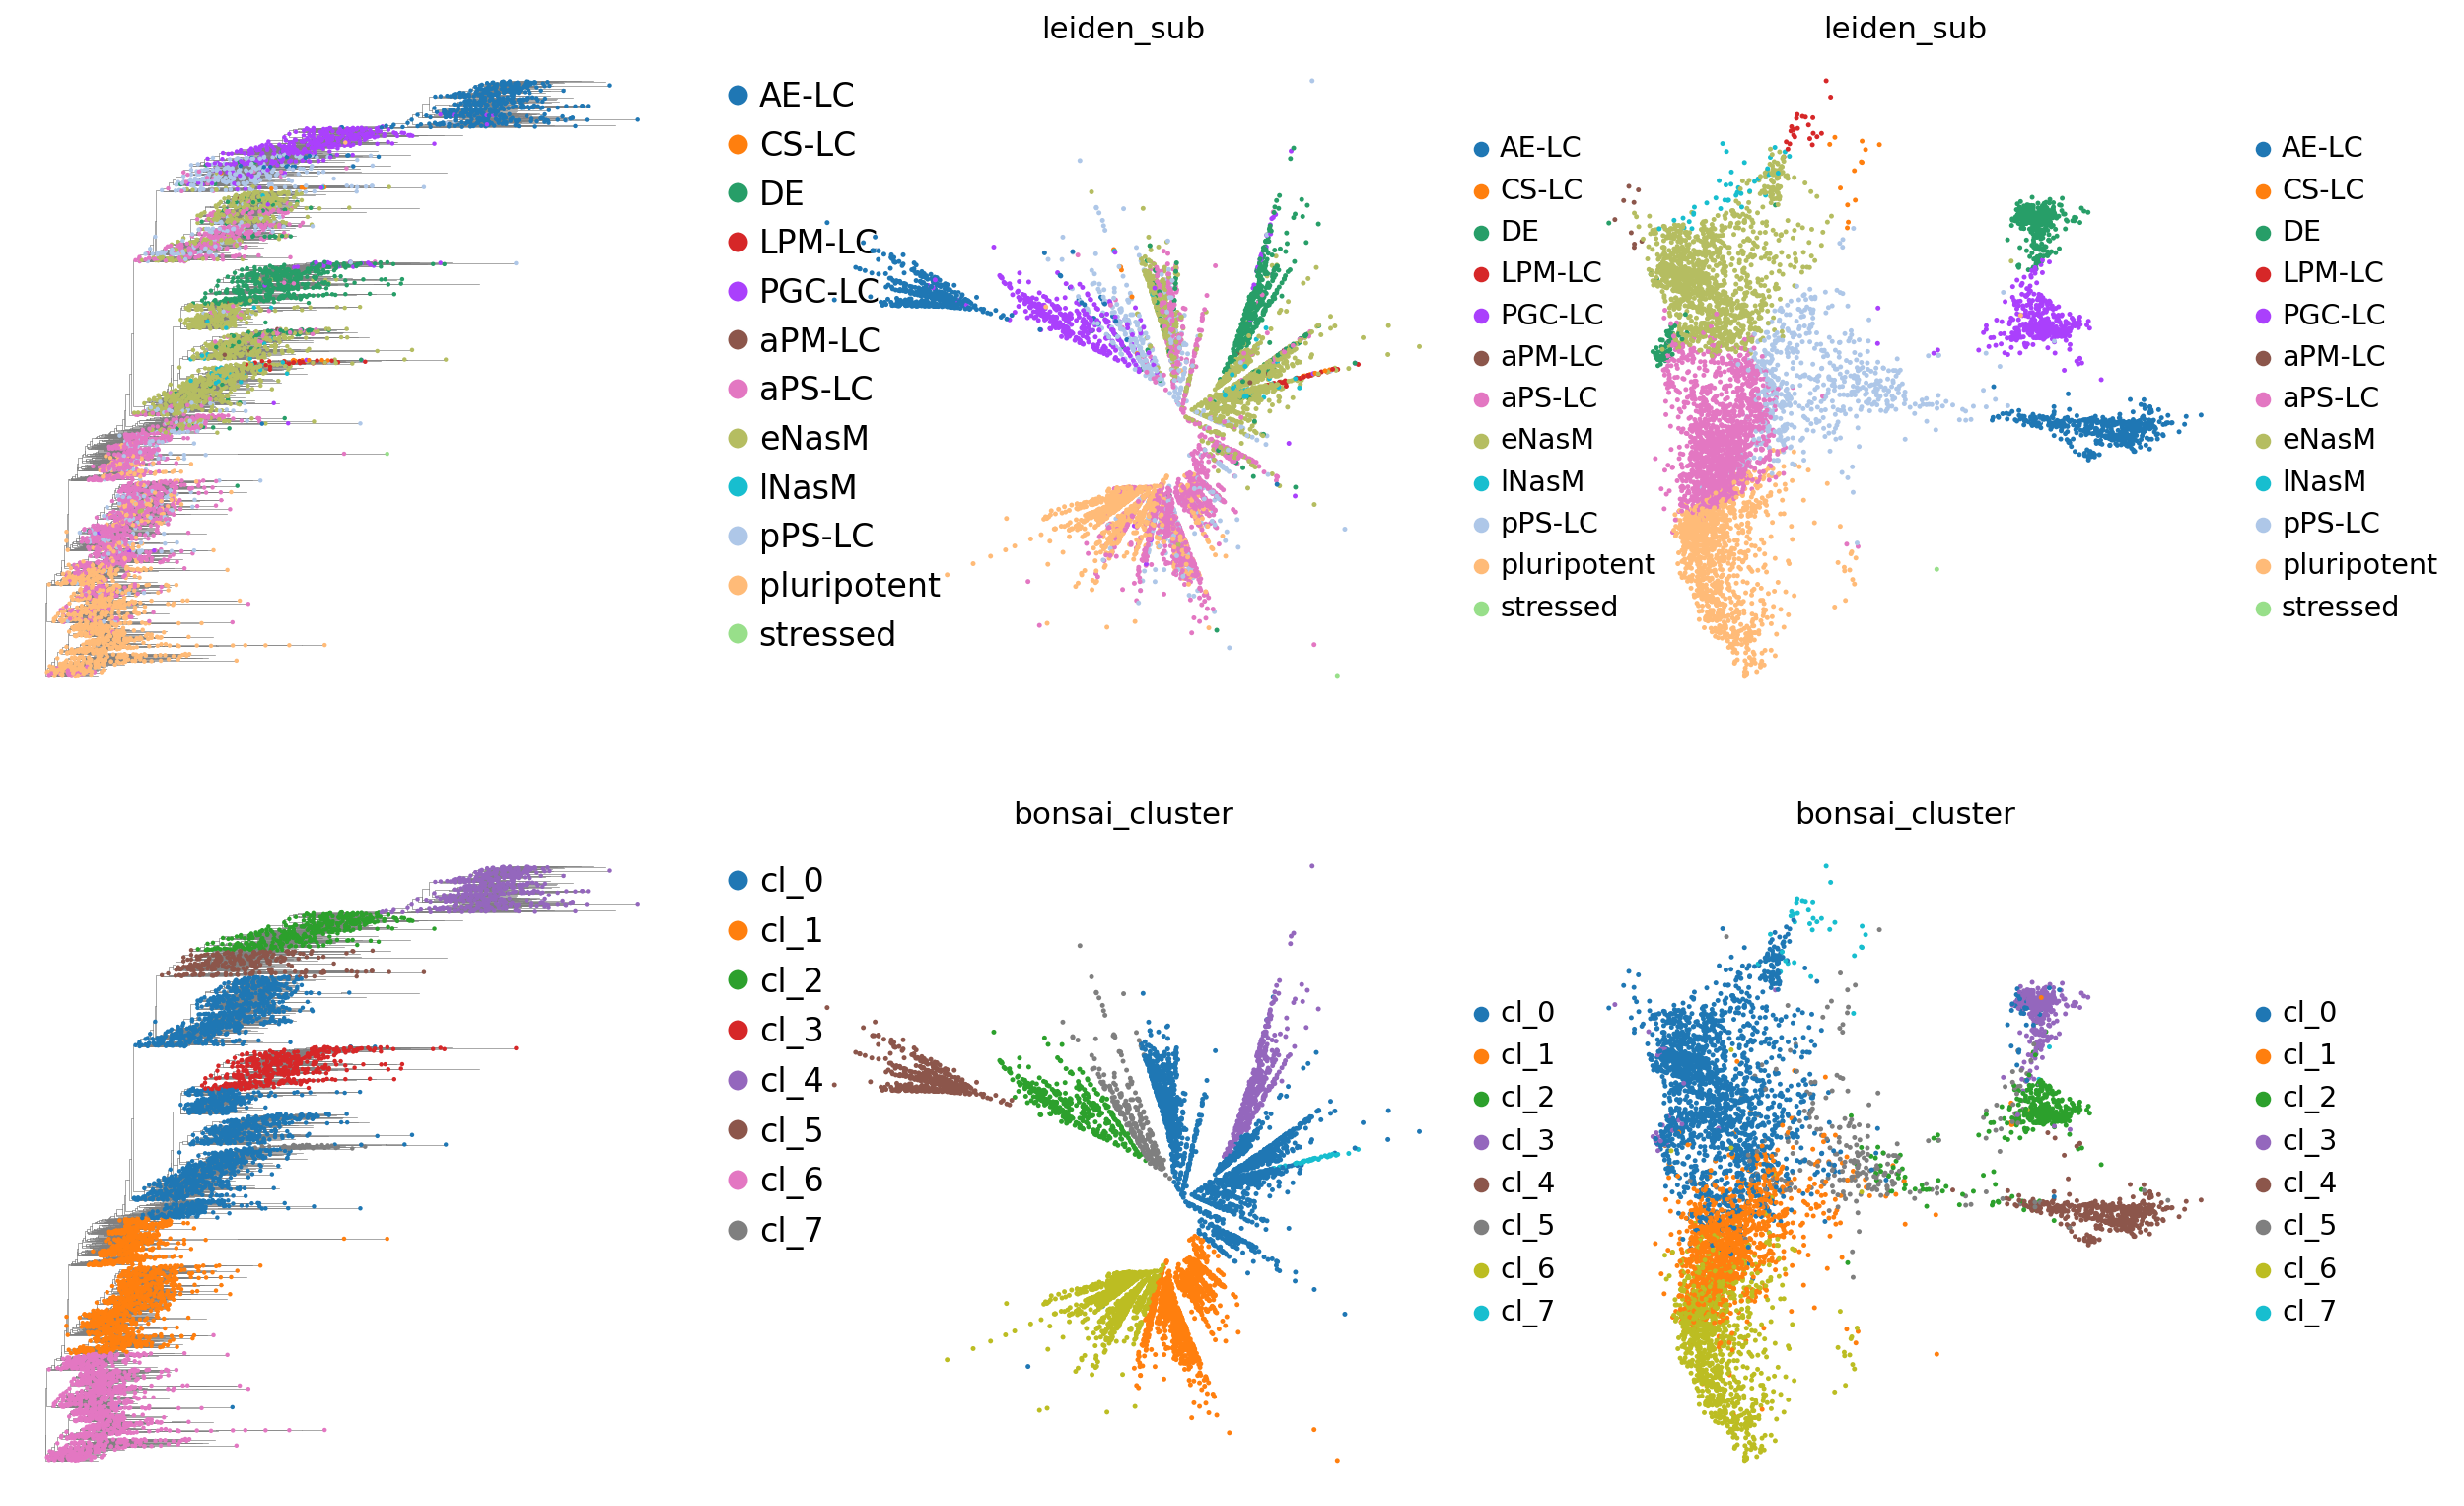

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(24 * 0.75, 16 * 0.75))
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

ax = axes[0, 0]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

ax = axes[1, 0]

categories_bc = adata.obs["bonsai_cluster"].cat.categories
palette = dict(zip(categories_bc, plt.cm.tab10.colors[: len(categories_bc)]))
cell_colors_bc = [palette[c] for c in adata.obs["bonsai_cluster"]]
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors_bc, zorder=3)
ax.set_aspect("auto")
handles_bc = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[c],
        markersize=10,
        label=c,
    )
    for c in categories_bc
]
ax.legend(
    handles=handles_bc,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

ax = axes[0, 1]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=ax,
    show=False,
    s=20,
    frameon=False,
)
ax = axes[1, 1]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=ax,
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
ax = axes[0, 2]
sc.pl.umap(
    adata,
    color="leiden_sub",
    ax=ax,
    show=False,
    s=20,
    frameon=False,
)
ax = axes[1, 2]
sc.pl.umap(
    adata,
    color="bonsai_cluster",
    ax=ax,
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
plt.savefig(
    "bonsai_micropattern_48h-1_summary_figure.png", dpi=300, bbox_inches="tight"
)

In [292]:
SOURCE_KEY = "PGC-DE_hodge_knn"  # or "PGC-DE_hodge"
EMB_KEY = "X_diffmap"
N_NEIGHBORS_POS = 15
N_NEIGHBORS_NEG = 10
N_ROUNDS_POS = 10
N_ROUNDS_NEG = 10
JITTER_STD_POS = 0.1
JITTER_STD_NEG = 0.11
RNG_SEED = 0
OUT_KEY = "PGC-DE_hodge_knn_smooth_sep"

rng = np.random.default_rng(RNG_SEED)

h = adata.obs[SOURCE_KEY].astype(float).values
valid_mask = ~np.isnan(h)
pos_mask = valid_mask & (h > 0)
neg_mask = valid_mask & (h < -0)

adata.obs[OUT_KEY] = np.nan

# positive stream
if pos_mask.sum() > 0:
    adata_pos_ref = adata[pos_mask].copy()
    adata_pos_ref.obsm["h_pos_s0"] = h[pos_mask][:, None]
    current_key = "h_pos_s0"

    for r in range(1, N_ROUNDS_POS + 1):
        q = adata[pos_mask].copy()
        if JITTER_STD_POS > 0:
            q.obsm[EMB_KEY] = q.obsm[EMB_KEY] + rng.normal(
                loc=0.0, scale=JITTER_STD_POS, size=q.obsm[EMB_KEY].shape
            )

        next_key = f"h_pos_s{r}"
        mic.knn.knn_transfer_layout(
            adata_pos_ref,
            q,
            EMB_KEY,
            layout_key=current_key,
            n_neighbors=N_NEIGHBORS_POS,
            key_added=next_key,
        )
        adata_pos_ref.obsm[next_key] = q.obsm[next_key].copy()
        current_key = next_key

    adata.obs.loc[pos_mask, OUT_KEY] = adata_pos_ref.obsm[current_key].ravel()

# negative stream
if neg_mask.sum() > 0:
    adata_neg_ref = adata[neg_mask].copy()
    adata_neg_ref.obsm["h_neg_s0"] = h[neg_mask][:, None]
    current_key = "h_neg_s0"

    for r in range(1, N_ROUNDS_NEG + 1):
        q = adata[neg_mask].copy()
        if JITTER_STD_NEG > 0:
            q.obsm[EMB_KEY] = q.obsm[EMB_KEY] + rng.normal(
                loc=0.0, scale=JITTER_STD_NEG, size=q.obsm[EMB_KEY].shape
            )

        next_key = f"h_neg_s{r}"
        mic.knn.knn_transfer_layout(
            adata_neg_ref,
            q,
            EMB_KEY,
            layout_key=current_key,
            n_neighbors=N_NEIGHBORS_NEG,
            key_added=next_key,
        )
        adata_neg_ref.obsm[next_key] = q.obsm[next_key].copy()
        current_key = next_key

    adata.obs.loc[neg_mask, OUT_KEY] = adata_neg_ref.obsm[current_key].ravel()

print("done", OUT_KEY, "| pos:", pos_mask.sum(), "neg:", neg_mask.sum())

# ...existing code...
# ...existing code...

# --- robust linear scaling by sign (quantile clipped) + center gap ---
OUT_KEY_LIN = f"{OUT_KEY}_lin"
Q_LOW, Q_HIGH = 0.02, 0.98
CENTER_GAP = 0.2  # 0..1, try 0.08-0.20

x = adata.obs[OUT_KEY].astype(float).values
y = np.full_like(x, np.nan, dtype=float)

pos = ~np.isnan(x) & (x > 0)
neg = ~np.isnan(x) & (x < 0)
zer = ~np.isnan(x) & (x == 0)

if np.any(pos):
    xp = x[pos]
    lo, hi = np.quantile(xp, [Q_LOW, Q_HIGH])
    xp = np.clip(xp, lo, hi)
    yp = (xp - lo) / (hi - lo) if hi > lo else np.ones_like(xp)
    y[pos] = CENTER_GAP + yp

if np.any(neg):
    xn = np.abs(x[neg])
    lo, hi = np.quantile(xn, [Q_LOW, Q_HIGH])
    xn = np.clip(xn, lo, hi)
    yn = (xn - lo) / (hi - lo) if hi > lo else np.ones_like(xn)
    y[neg] = -(CENTER_GAP + yn)

y[zer] = 0.0
adata.obs[OUT_KEY_LIN] = y
print("done robust linear scaling + center gap ->", OUT_KEY_LIN)
# ...existing code...


Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 15 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... Weighted KNN with n_neighbors = 10 ... done PGC-DE_hodge_knn_smooth_sep | pos: 1026 neg: 239
done robust linear scaling + center gap -> PGC-DE_hodge_knn_smooth_sep_lin


[<Axes: title={'center': 'PGC-DE_hodge_knn_smooth'}, xlabel='X_diffmap2', ylabel='X_diffmap3'>,
 <Axes: title={'center': 'PGC-DE_hodge_knn_smooth_sep'}, xlabel='X_diffmap2', ylabel='X_diffmap3'>,
 <Axes: title={'center': 'PGC-DE_hodge_knn_smooth_sep_lin'}, xlabel='X_diffmap2', ylabel='X_diffmap3'>,
 <Axes: title={'center': 'PGC-DE_hodge_knn'}, xlabel='X_diffmap2', ylabel='X_diffmap3'>]

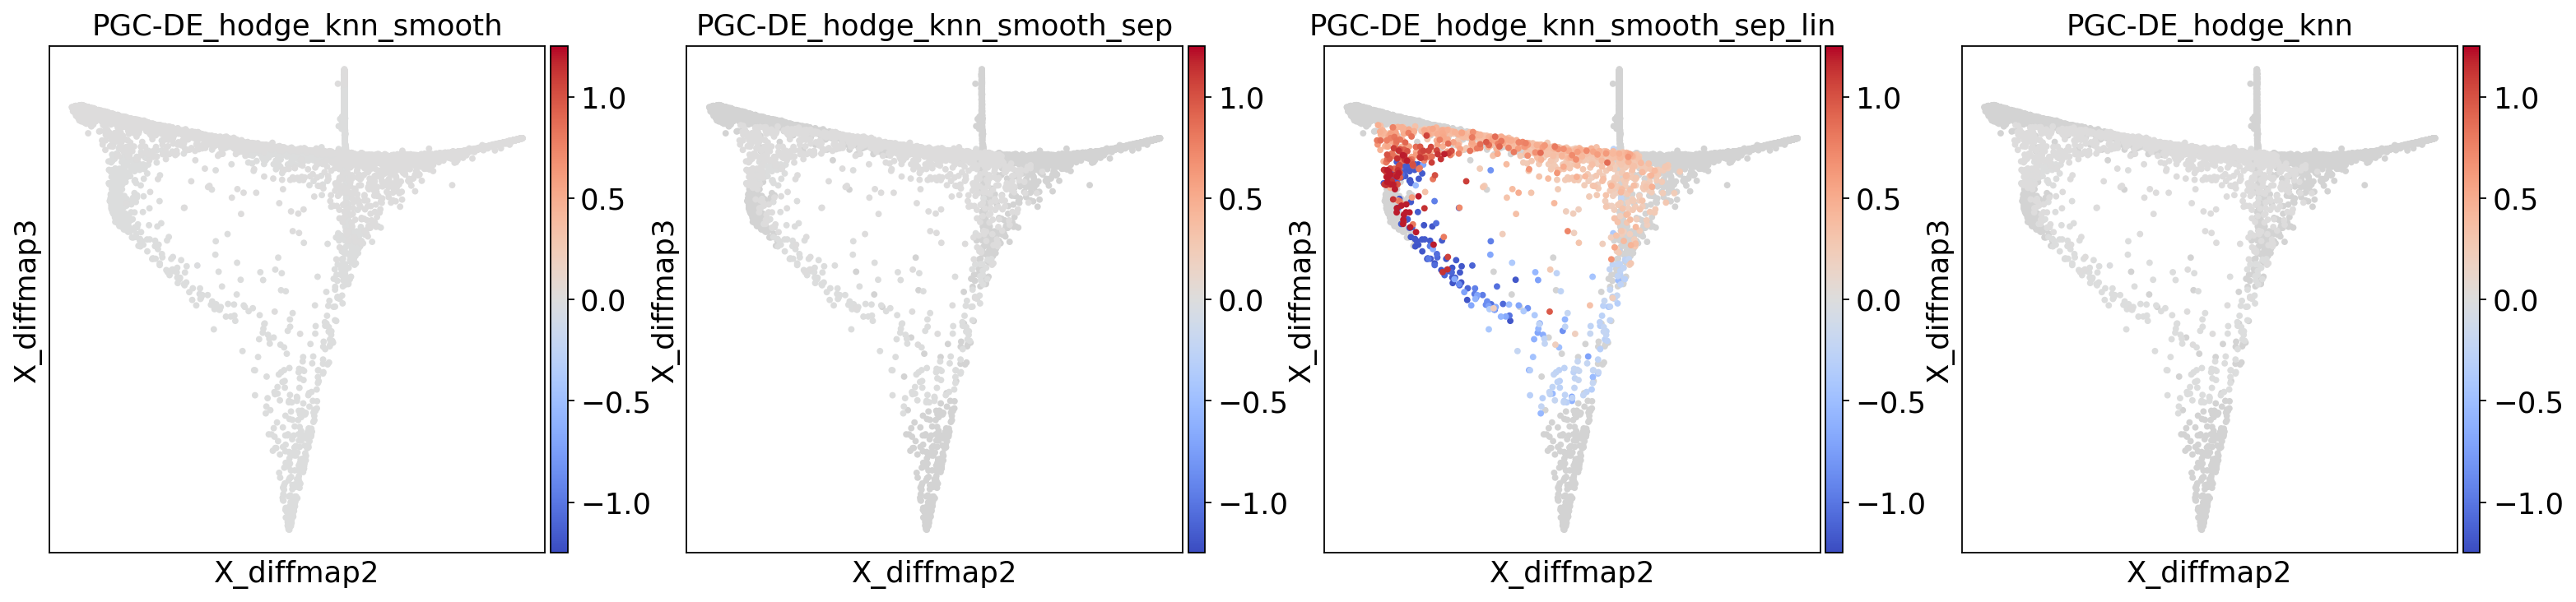

In [293]:
sc.pl.embedding(
    adata,
    color=[
        "PGC-DE_hodge_knn_smooth",
        "PGC-DE_hodge_knn_smooth_sep",
        "PGC-DE_hodge_knn_smooth_sep_lin",
        "PGC-DE_hodge_knn",
    ],
    basis="X_diffmap",
    s=50,
    show=False,
    components=["2,3"],
    cmap="coolwarm",
    vmax=1.25,
    vmin=-1.25,
)

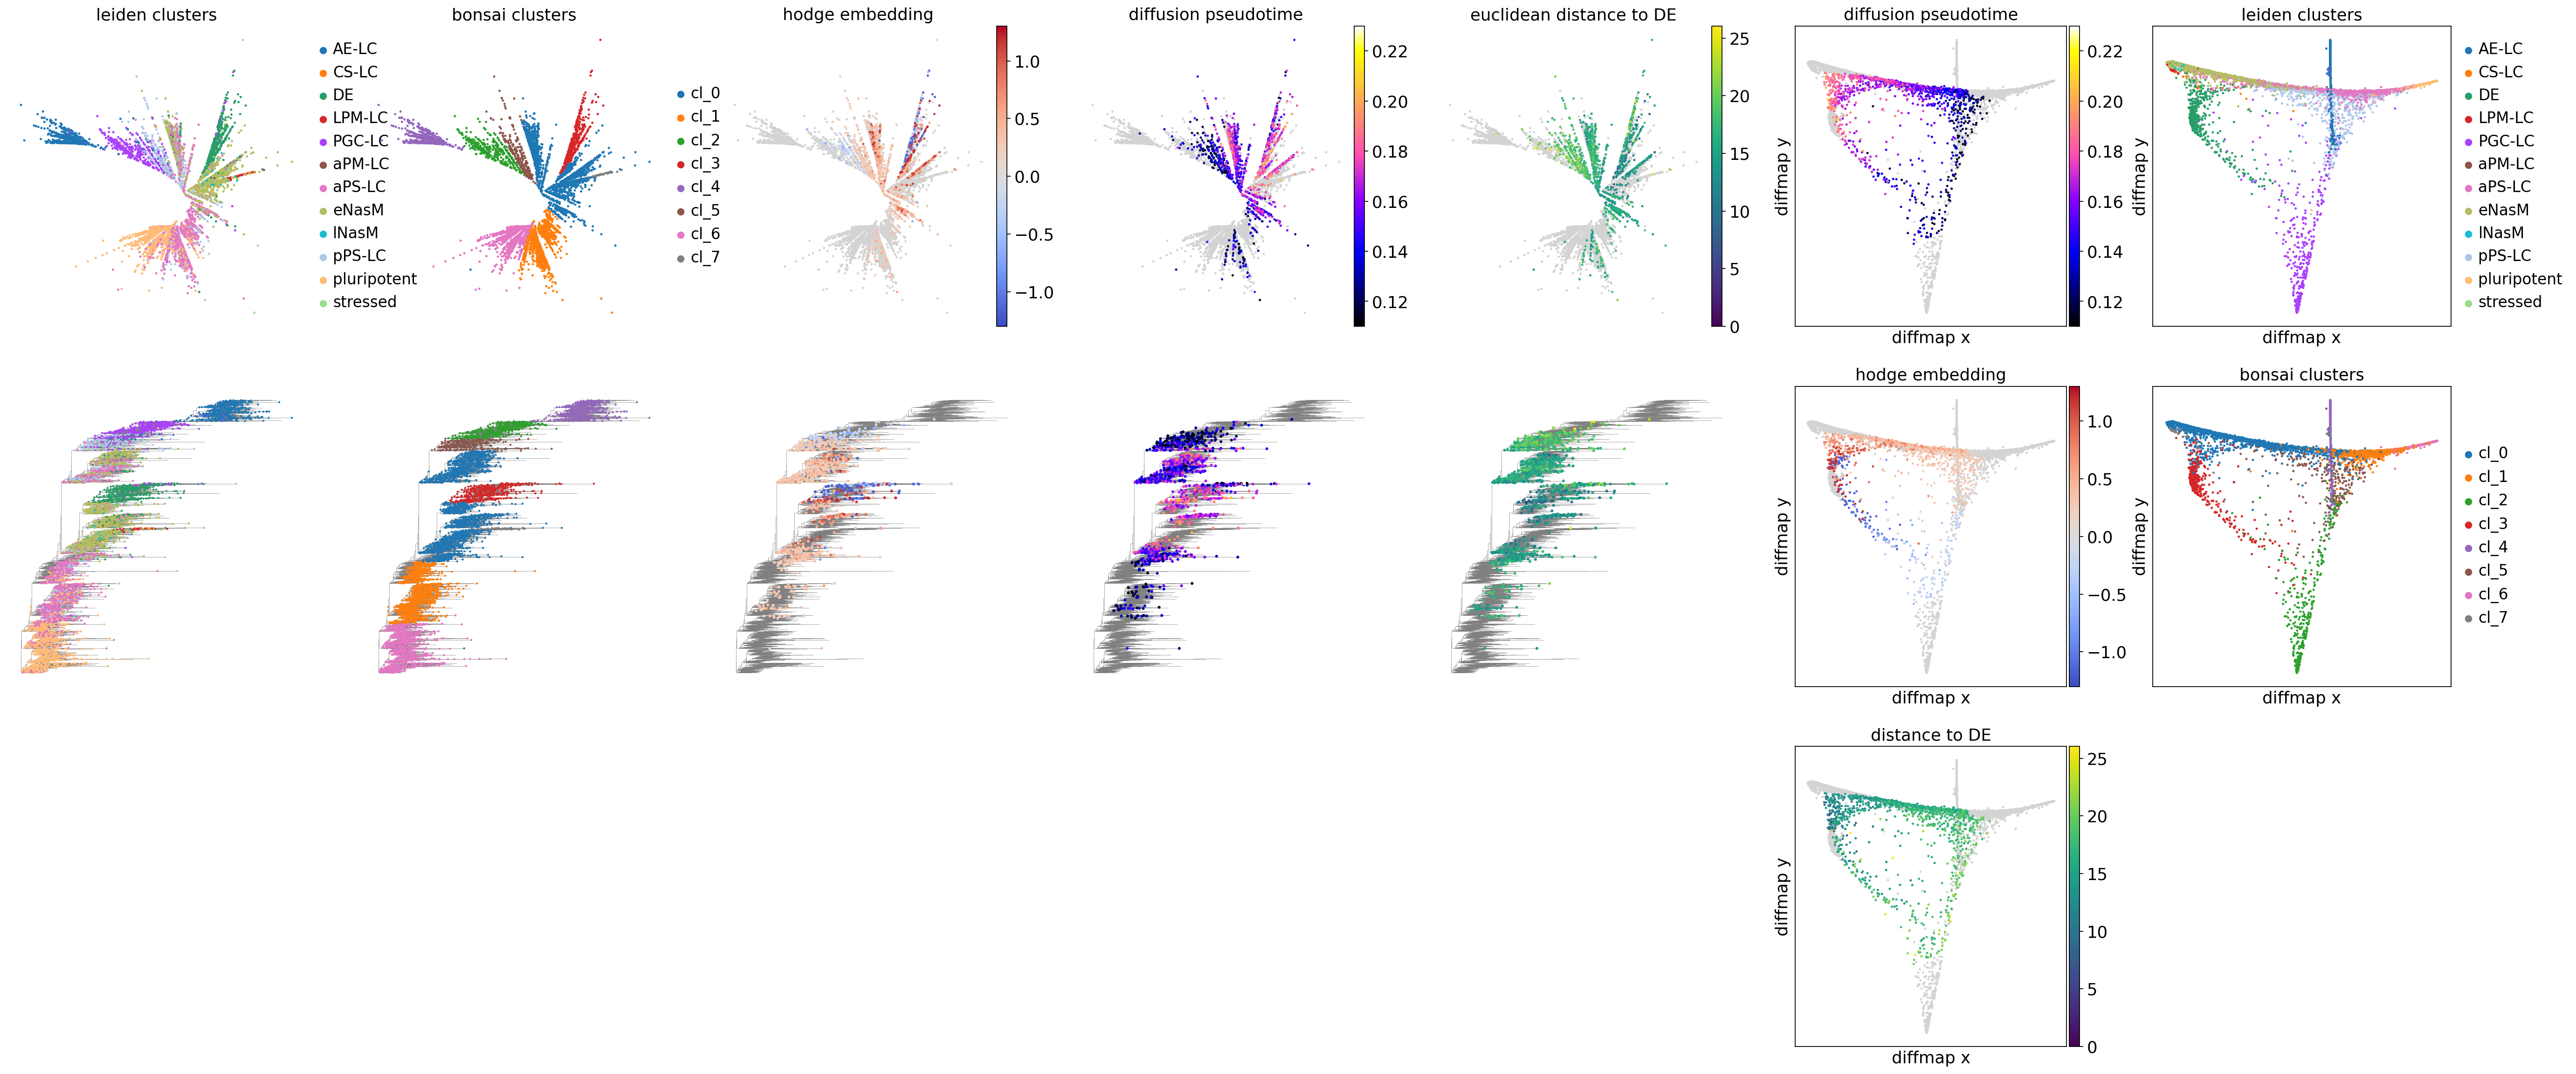

In [338]:
sc.set_figure_params(figsize=(5, 5), fontsize=16)
fig, axes = plt.subplots(3, 7, figsize=(56 * 0.75, 24 * 0.75))
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

ax = axes[1, 0]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

ax = axes[1, 1]

categories_bc = adata.obs["bonsai_cluster"].cat.categories
palette = dict(zip(categories_bc, plt.cm.tab10.colors[: len(categories_bc)]))
cell_colors_bc = [palette[c] for c in adata.obs["bonsai_cluster"]]
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors_bc, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

ax = axes[1, 2]

# Get continuous Hodge values and map to coolwarm
import matplotlib.colors as mcolors

hodge_vals = adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"].values.astype(float)
norm = mcolors.Normalize(vmin=-1.3, vmax=1.3)
cmap = plt.cm.coolwarm
cell_colors = cmap(norm(hodge_vals))

# (reuse existing coords_d, edge_coords_d, cell_coords_d from above)

ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=3, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")


ax = axes[0, 0]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=ax,
    show=False,
    s=20,
    frameon=False,
    title="leiden clusters",
)
ax = axes[0, 1]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=ax,
    show=False,
    s=20,
    palette=palette,
    frameon=False,
    title="bonsai clusters",
)
ax = axes[0, 2]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color=["PGC-DE_hodge_knn_smooth_sep_lin"],
    ax=ax,
    show=False,
    s=20,
    frameon=False,
    cmap="coolwarm",
    vmin=-1.3,
    vmax=1.3,
    na_in_legend=False,
    title="hodge embedding",
)

ax = axes[0, 5]
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    cmap="gnuplot2",
    frameon=True,
    title="diffusion pseudotime",
)
sc.pl.embedding(
    adata[~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"])],
    basis="X_diffmap",
    color="dpt_pseudotime",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    cmap="gnuplot2",
    frameon=True,
    title="diffusion pseudotime",
)
ax.set_xlabel("diffmap x")
ax.set_ylabel("diffmap y")
ax = axes[1, 5]
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    color=["PGC-DE_hodge_knn_smooth_sep_lin"],
    s=20,
    show=False,
    components=["2,3"],
    vmin=-1.3,
    vmax=1.3,
    ax=ax,
    cmap="coolwarm",
    frameon=True,
    title="hodge embedding",
)
ax.set_xlabel("diffmap x")
ax.set_ylabel("diffmap y")
ax = axes[0, 6]
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    color="leiden_sub",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    frameon=True,
    title="leiden clusters",
)
ax.set_xlabel("diffmap x")
ax.set_ylabel("diffmap y")
ax = axes[1, 6]
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    color="bonsai_cluster",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    frameon=True,
    title="bonsai clusters",
)
ax.set_xlabel("diffmap x")
ax.set_ylabel("diffmap y")

ax = axes[0, 3]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    show=False,
    s=20,
    frameon=False,
    cmap="gnuplot2",
    na_in_legend=False,
    title="diffusion pseudotime",
    ax=ax,
)
sc.pl.embedding(
    adata[~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"])],
    basis="X_bonsai",
    color=["dpt_pseudotime"],  # or another key you prefer
    ax=ax,
    show=False,
    s=20,
    frameon=False,
    cmap="gnuplot2",
    na_in_legend=False,
    title="diffusion pseudotime",
)


ax = axes[1, 3]

import matplotlib.colors as mcolors

# restrict to cells with non-NA hodge
mask_hodge = ~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"]).values
dpt_vals = adata.obs["dpt_pseudotime"].astype(float).values

# transparent by default; color only masked cells
cell_colors_dpt = np.zeros((adata.n_obs, 4), dtype=float)
norm_dpt = mcolors.Normalize(
    vmin=np.nanmin(dpt_vals[mask_hodge]),
    vmax=np.nanmax(dpt_vals[mask_hodge]),
)
cell_colors_dpt[mask_hodge] = plt.cm.gnuplot2(norm_dpt(dpt_vals[mask_hodge]))

# draw dendrogram
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=3, c=cell_colors_dpt, zorder=3)
ax.set_aspect("auto")
ax.axis("off")


ax = axes[0, 4]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    show=False,
    s=20,
    frameon=False,
    cmap="viridis",
    na_in_legend=False,
    title="diffusion pseudotime",
    ax=ax,
)
sc.pl.embedding(
    adata[~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"])],
    basis="X_bonsai",
    color=["distance_to_root"],  # or another key you prefer
    ax=ax,
    show=False,
    s=20,
    frameon=False,
    cmap="viridis",
    na_in_legend=False,
    title="euclidean distance to DE",
)

# ...existing code...
# ...existing code...

ax = axes[1, 4]

import matplotlib.colors as mcolors

# restrict to cells with non-NA hodge
mask_hodge = ~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"]).values
dpt_vals = adata.obs["distance_to_root"].astype(float).values

# transparent by default; color only masked cells
cell_colors_dpt = np.zeros((adata.n_obs, 4), dtype=float)
norm_dpt = mcolors.Normalize(
    vmin=np.nanmin(dpt_vals[mask_hodge]),
    vmax=np.nanmax(dpt_vals[mask_hodge]),
)
cell_colors_dpt[mask_hodge] = plt.cm.viridis(norm_dpt(dpt_vals[mask_hodge]))

# draw dendrogram
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=3, c=cell_colors_dpt, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

ax = axes[2, 5]
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    cmap="gnuplot2",
    frameon=True,
    title="diffusion pseudotime",
)
sc.pl.embedding(
    adata[~pd.isna(adata.obs["PGC-DE_hodge_knn_smooth_sep_lin"])],
    basis="X_diffmap",
    color="distance_to_root",
    components=["2,3"],
    ax=ax,
    show=False,
    s=20,
    cmap="viridis",
    frameon=True,
    title="distance to DE",
)
ax.set_xlabel("diffmap x")
ax.set_ylabel("diffmap y")

for i in range(5):
    axes[2, i].axis("off")
axes[2, 6].axis("off")


# sc.pl.embedding(
#     adata,
#     basis="X_diffmap",
#     color=["PGC-DE_hodge_knn_smooth_sep_lin"],
#     s=20,
#     show=False,
#     components=["2,3"],
#     vmin=-0.003,
#     vmax=0.003,
#     ax=ax,
#     cmap="coolwarm",
# )
plt.savefig("bonsai_micropattern_48h-1_loop.png", dpi=300, bbox_inches="tight")

In [324]:
reference_coord = adata.obsm["X_pca"][adata.uns["iroot"], :]
distances_to_root = np.linalg.norm(adata.obsm["X_pca"] - reference_coord, axis=1)
adata.obs["distance_to_root"] = distances_to_root

In [323]:
sc.pp.pca(adata, n_comps=50, layer="sanity_log_mean")

<Axes: title={'center': 'distance_to_root'}, xlabel='X_diffmap2', ylabel='X_diffmap3'>

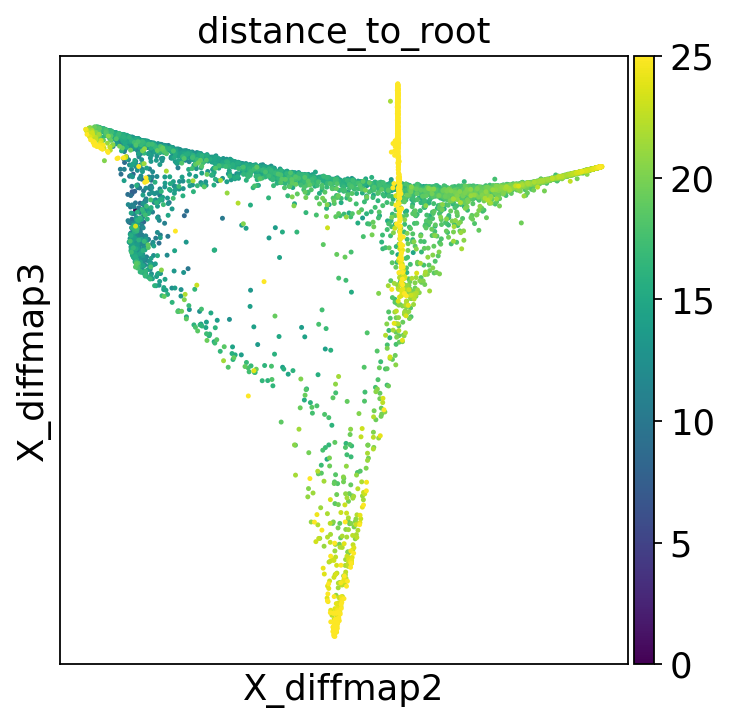

In [331]:
sc.pl.embedding(
    adata,
    basis="X_diffmap",
    color="distance_to_root",
    components=["2,3"],
    show=False,
    s=20,
    cmap="viridis",
    vmax=25,
)

In [84]:
adata.obs["in_loop_knn_filt"] = adata.obs["in_loop_knn"].copy()
adata.obs.loc[
    adata.obs["leiden_sub"].str.contains("AE|pluri|LPM"), "in_loop_knn_filt"
] = None